# 📈 Multi-Factor Risk, Corporate Bankruptcy & Customer Lifetime Value (CLV) Modeling
### For Financial Products: **Hedge Funds** and **M&A Advisory**

**What this notebook does (in plain English)**

| Step | Question it answers | Technique |
|---|---|---|
| 1 | *How risky is the market/stock I picked?* | Multi-factor risk (volatility, beta, drawdown, VaR, Sharpe…) + a daily **Market Stress Index** |
| 2 | *Is a company financially healthy or heading toward bankruptcy?* | **Altman Z-Score** (a classic bankruptcy model) |
| 3 | *Who are our clients and how do they behave over time?* | Client data + time-stamped transactions |
| 4 | *Which clients stay, which leave?* | **Cohort analysis** |
| 5 | *How long will a client stay?* | **Survival modeling** (Kaplan-Meier + Cox regression) |
| 6 | *How much money will each client bring in the next 12 months?* | **ML regression** (XGBoost / GradientBoosting / RandomForest / Ridge) |
| 7 | *Which clients matter most?* | Survival-adjusted CLV, client tiers, Pareto chart |

**Data source:** Yahoo Finance (`yfinance`) – free, no API key, and works for **Indian (`.NS` / `.BO`) and Global** tickers.
(Alpha Vantage's free tier allows only ~25 calls/day and has patchy Indian coverage, so Yahoo is the better choice here.)

**How the "customers" work:** public data has no real client records, so the notebook *simulates* realistic clients (hedge-fund investors, M&A advisory clients, structured-product buyers) whose behavior is linked to the market stress of **your chosen ticker**. Want to use your own data? Set `CUSTOMERS_CSV` and `TRANSACTIONS_CSV` in the control panel.

> ⭐ **Everything you may want to change is in ONE cell: "Control Panel" (Section 0).** Run all cells top to bottom (Runtime ▸ Run all).

## 0️⃣ Setup

In [ ]:
!pip -q install yfinance lifelines xgboost

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 6.1 MB/s eta 0:00:00


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                  ⭐⭐⭐  CONTROL PANEL  (edit here)  ⭐⭐⭐             ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── 1) MARKET / STOCK CHOICE ─────────────────────────────────────────────
TICKER        = "RELIANCE.NS"   # ⭐ ANY Yahoo ticker. India: "TCS.NS", "HDFCBANK.NS", "^NSEI" | Global: "AAPL", "MSFT", "JPM", "BX", "KKR"
BENCHMARK     = "^NSEI"         # ⭐ Market index used for beta. India: "^NSEI"(Nifty50) "^BSESN"(Sensex) | Global: "^GSPC"(S&P500)
PEER_TICKERS  = ["TCS.NS", "INFY.NS", "ITC.NS"]   # ⭐ Other companies to compare for bankruptcy (Altman Z). [] to skip
START_DATE    = "2019-01-01"    # ⭐ history start
END_DATE      = None            # None = today, or "2026-09-01"
RISK_FREE_RATE = 0.065          # ⭐ annual risk-free rate (India ≈ 6.5%, US ≈ 4-5%)
ROLLING_WINDOW = 30             # ⭐ days used for rolling volatility
VAR_CONFIDENCE = 0.95           # ⭐ Value-at-Risk confidence (0.95 or 0.99)
STRESS_WEIGHTS = {"volatility": 0.5, "drawdown": 0.5}   # ⭐ how the Market Stress Index is built

# ── 2) CLIENT (CUSTOMER) DATA ────────────────────────────────────────────
N_CUSTOMERS    = 3000           # ⭐ number of simulated clients
RANDOM_STATE   = 42             # ⭐ change for a different random world
CUSTOMERS_CSV    = None         # ⭐ OPTIONAL own data: needs columns customer_id, signup_date (+ any demographics)
TRANSACTIONS_CSV = None         # ⭐ OPTIONAL own data: needs columns customer_id, date, amount
CURRENCY       = "₹"

# Simulation knobs per product line  (ticket = avg revenue per transaction, gap = avg days between
# transactions, life = typical days a client stays, p = share of clients)
SEGMENT_SETTINGS = {
    "Hedge Fund LP":       dict(ticket=25000,  gap=45,  life=1800, p=0.45),
    "M&A Advisory Client": dict(ticket=150000, gap=100, life=1500, p=0.20),
    "Structured Products": dict(ticket=8000,   gap=30,  life=1400, p=0.35),
}
MARKET_STRESS_IMPACT = 0.8      # ⭐ 0 = clients ignore market stress, 1 = strongly reduce activity in stress

# ── 3) CLV / SURVIVAL DEFINITIONS ────────────────────────────────────────
CLV_HORIZON_DAYS      = 365     # ⭐ predict revenue over the next N days
CHURN_INACTIVITY_DAYS = 240     # ⭐ no transaction for N days  => client counted as "churned"
MIN_HISTORY_DAYS      = 90      # ⭐ only model clients with at least N days of history
COX_PENALIZER         = 0.1     # ⭐ survival model regularization (higher = simpler/more stable)
BLEND_WEIGHT_ML       = 0.7     # ⭐ final CLV = w*ML + (1-w)*Survival-based
TIER_CUTS             = {"Platinum": 0.10, "Gold": 0.30, "Silver": 0.60}   # ⭐ top 10% / next 20% / next 30% / rest = Bronze

# ── 4) MACHINE-LEARNING MODEL  (⭐ THE IMPORTANT PART TO FINE-TUNE) ───────
MODEL_CHOICE = "xgboost"        # ⭐ "xgboost" | "gbr" (GradientBoosting) | "rf" (RandomForest) | "ridge" (linear)
LOG_TARGET   = False            # ⭐ False = best money accuracy (MAE/R²). True = models log(1+revenue): better client RANKING, but underestimates big spenders
TEST_SIZE    = 0.25             # ⭐ share of clients held out for testing

MODEL_PARAMS = {                # ⭐ hyper-parameters for each model – tweak freely
    "xgboost": dict(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8,
                    colsample_bytree=0.8, min_child_weight=3, reg_lambda=1.0),
    "gbr":     dict(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, min_samples_leaf=10),
    "rf":      dict(n_estimators=400, max_depth=8, min_samples_leaf=5, max_features="sqrt"),
    "ridge":   dict(alpha=1.0),
}

RUN_TUNING = False              # ⭐ True = auto-search best parameters (slower, ~1-3 min)
TUNING_N_ITER, TUNING_CV = 15, 3
TUNING_GRID = {                 # ⭐ search space used when RUN_TUNING=True
    "xgboost": {"n_estimators": [200, 400, 600], "learning_rate": [0.02, 0.05, 0.1],
                "max_depth": [3, 4, 6], "subsample": [0.7, 0.85, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0], "min_child_weight": [1, 3, 6]},
    "gbr":     {"n_estimators": [200, 300, 500], "learning_rate": [0.02, 0.05, 0.1],
                "max_depth": [2, 3, 4], "min_samples_leaf": [5, 10, 20]},
    "rf":      {"n_estimators": [300, 500], "max_depth": [6, 8, 12, None], "min_samples_leaf": [2, 5, 10]},
    "ridge":   {"model__alpha": [0.01, 0.1, 1, 10, 100]},
}
print("✅ Control panel loaded. Ticker:", TICKER, "| Benchmark:", BENCHMARK, "| Model:", MODEL_CHOICE)

✅ Control panel loaded. Ticker: RELIANCE.NS | Benchmark: ^NSEI | Model: xgboost


In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import spearmanr
from IPython.display import display, HTML
from lifelines import KaplanMeierFitter, CoxPHFitter
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor; HAS_XGB = True
except Exception:
    HAS_XGB = False

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold"})

def explain(title, text):
    """Blue 'how to read this chart' box for non-technical readers."""
    display(HTML(f"<div style='background:#eef6ff;border-left:5px solid #2b7de9;padding:10px 14px;"
                 f"margin:6px 0 18px 0;font-size:14px;color:#111;line-height:1.5'><b>📖 {title}</b><br>{text}</div>"))

def money(x):
    return f"{CURRENCY}{x:,.0f}"

## 1️⃣ Download Market Data (Yahoo Finance)
Works for Indian and global tickers. If the download fails (no internet, bad ticker), the notebook falls back to **demo data** so it never crashes.

In [ ]:
def get_prices(ticker, start, end):
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        s = df["Close"].dropna()
        s.index = pd.to_datetime(s.index).tz_localize(None)
        if len(s) < 250:
            raise ValueError("fewer than 250 rows returned")
        return s.rename(ticker)
    except Exception as e:
        print(f"⚠️  Could not download {ticker}: {e}")
        return None

def fake_prices(seed, start, end, drift=0.10, vol=0.25):
    idx = pd.bdate_range(start, end or pd.Timestamp.today().normalize())
    r = np.random.default_rng(seed).normal(drift/252, vol/np.sqrt(252), len(idx))
    return pd.Series(1000*np.exp(np.cumsum(r)), index=idx)

price = get_prices(TICKER, START_DATE, END_DATE)
bench = get_prices(BENCHMARK, START_DATE, END_DATE)
DEMO_MODE = False
if price is None:
    price, DEMO_MODE = fake_prices(1, START_DATE, END_DATE), True
    print("➡️  Using DEMO price series for the ticker.")
if bench is None:
    bench, DEMO_MODE = fake_prices(2, START_DATE, END_DATE, 0.08, 0.16), True
    print("➡️  Using DEMO price series for the benchmark.")

OBS_END   = price.index[-1].normalize()
MKT_START = price.index[0].normalize()
print(f"✅ {TICKER}: {len(price):,} trading days  ({MKT_START.date()} → {OBS_END.date()})   |  Last price: {price.iloc[-1]:,.2f}")

✅ RELIANCE.NS: 1,917 trading days  (2019-01-01 → 2026-09-28)   |  Last price: 1,197.60


## 2️⃣ Multi-Factor Market Risk Profile
We measure risk from several angles ("factors") instead of just one number.

In [ ]:
TD = 252
ret  = price.pct_change().dropna()
bret = bench.pct_change().dropna()
joined = pd.concat([ret, bret], axis=1, join="inner").dropna(); joined.columns = ["asset", "bench"]

ann_ret  = (price.iloc[-1]/price.iloc[0])**(TD/len(ret)) - 1
ann_vol  = ret.std()*np.sqrt(TD)
down_vol = ret[ret < 0].std()*np.sqrt(TD)
beta     = joined.cov().iloc[0, 1]/joined["bench"].var() if len(joined) > 30 else np.nan
dd       = price/price.cummax() - 1
max_dd   = dd.min()
var_q    = -np.percentile(ret, (1-VAR_CONFIDENCE)*100)
cvar_q   = -ret[ret <= -var_q].mean()
sharpe   = (ann_ret-RISK_FREE_RATE)/ann_vol
sortino  = (ann_ret-RISK_FREE_RATE)/down_vol
mom_6m   = price.iloc[-1]/price.iloc[max(-126, -len(price))] - 1

def rating(v, lo, hi):
    return "🟢 Low" if v < lo else ("🟡 Medium" if v < hi else "🔴 High")

risk_table = pd.DataFrame([
    ["Annual return (CAGR)",       f"{ann_ret:.1%}",  "Average yearly growth over the period."],
    ["Annual volatility",          f"{ann_vol:.1%}",  f"How wildly the price swings. {rating(ann_vol, .20, .35)}"],
    ["Downside volatility",        f"{down_vol:.1%}", "Swings on the DOWN days only – the 'bad' volatility."],
    ["Beta vs benchmark",          f"{beta:.2f}",     "1.0 = moves with the market; >1 = amplifies market moves; <1 = calmer."],
    ["Max drawdown",               f"{max_dd:.1%}",   f"Worst peak-to-bottom loss ever. {rating(-max_dd, .25, .45)}"],
    [f"Daily VaR ({VAR_CONFIDENCE:.0%})", f"{var_q:.2%}", f"On a normal day, you lose MORE than this only {1-VAR_CONFIDENCE:.0%} of the time."],
    [f"Daily CVaR ({VAR_CONFIDENCE:.0%})", f"{cvar_q:.2%}", "Average loss on those really bad days (worse than VaR)."],
    ["Sharpe ratio",               f"{sharpe:.2f}",   "Return per unit of risk. >1 good, >2 great, <0 poor."],
    ["Sortino ratio",              f"{sortino:.2f}",  "Like Sharpe but only penalises downside swings."],
    ["6-month momentum",           f"{mom_6m:.1%}",   "Recent trend: positive = rising, negative = falling."],
], columns=["Risk factor", "Value", "What it means"])
display(risk_table.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Risk factor,Value,What it means
Annual return (CAGR),12.3%,Average yearly growth over the period.
Annual volatility,27.6%,How wildly the price swings. 🟡 Medium
Downside volatility,18.6%,Swings on the DOWN days only – the 'bad' volatility.
Beta vs benchmark,1.09,1.0 = moves with the market; >1 = amplifies market moves; <1 = calmer.
Max drawdown,-45.1%,Worst peak-to-bottom loss ever. 🔴 High
Daily VaR (95%),2.31%,"On a normal day, you lose MORE than this only 5% of the time."
Daily CVaR (95%),3.62%,Average loss on those really bad days (worse than VaR).
Sharpe ratio,0.21,"Return per unit of risk. >1 good, >2 great, <0 poor."
Sortino ratio,0.31,Like Sharpe but only penalises downside swings.
6-month momentum,-10.9%,"Recent trend: positive = rising, negative = falling."


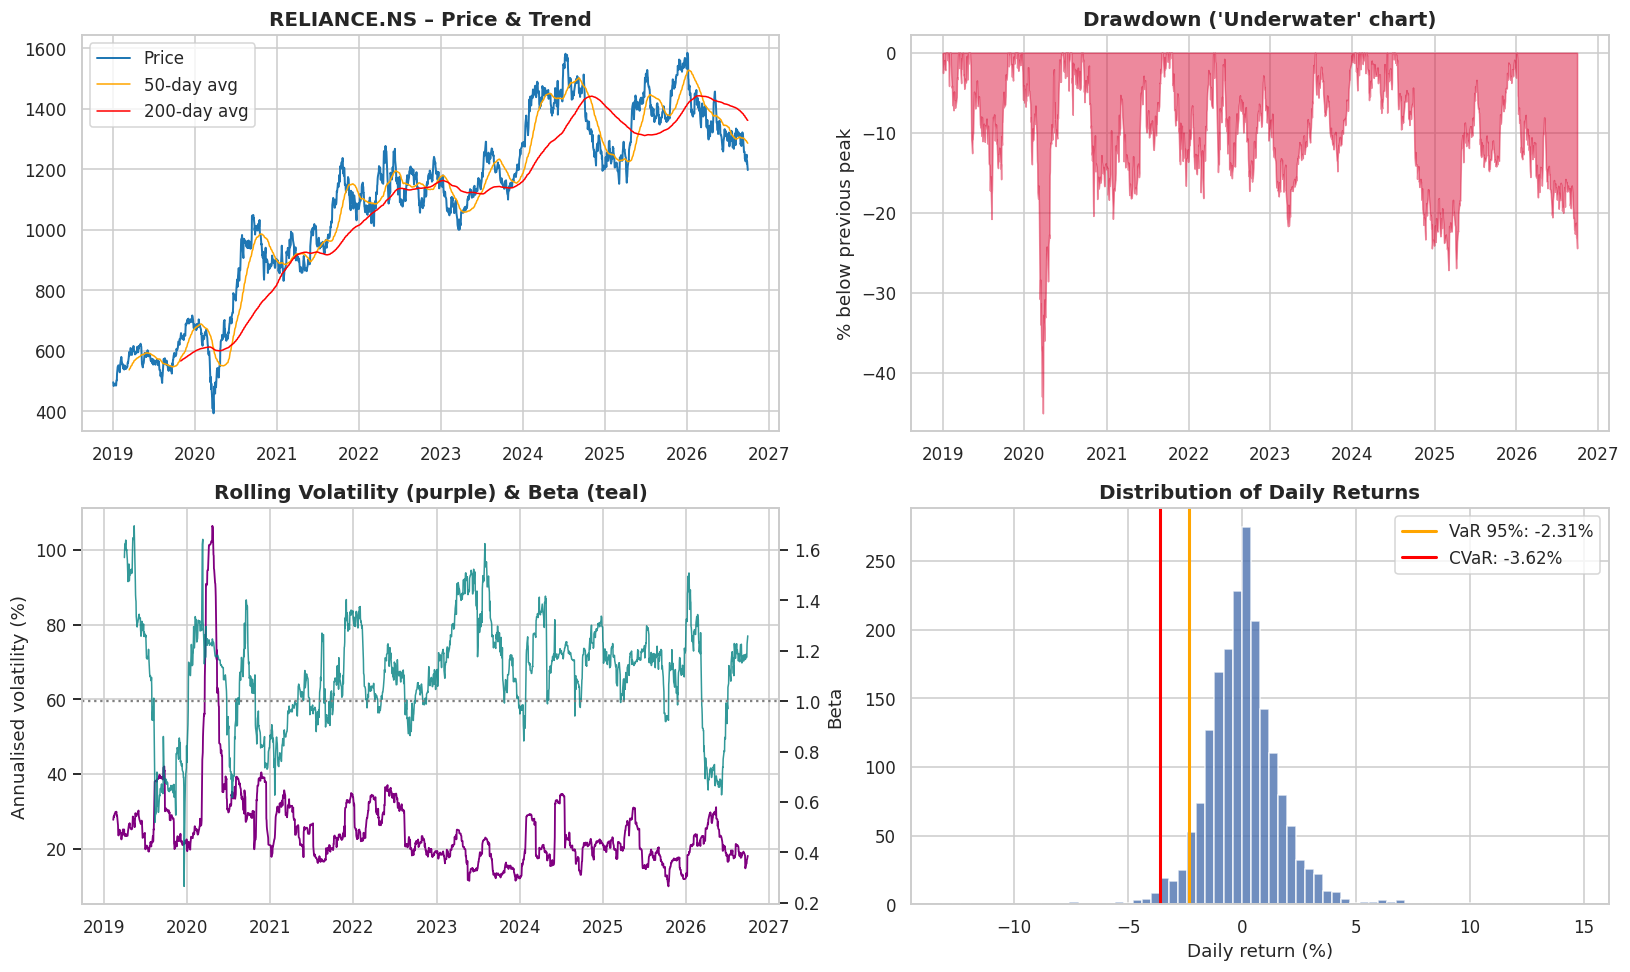

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# (a) price + moving averages
ax[0,0].plot(price, color="#1f77b4", lw=1.3, label="Price")
ax[0,0].plot(price.rolling(50).mean(),  color="orange", lw=1, label="50-day avg")
ax[0,0].plot(price.rolling(200).mean(), color="red",    lw=1, label="200-day avg")
ax[0,0].set_title(f"{TICKER} – Price & Trend"); ax[0,0].legend()

# (b) drawdown
ax[0,1].fill_between(dd.index, dd*100, 0, color="crimson", alpha=.5)
ax[0,1].set_title("Drawdown ('Underwater' chart)"); ax[0,1].set_ylabel("% below previous peak")

# (c) rolling volatility and beta
rv = ret.rolling(ROLLING_WINDOW).std()*np.sqrt(TD)*100
ax[1,0].plot(rv, color="purple", lw=1.2, label=f"{ROLLING_WINDOW}-day volatility (%)")
ax[1,0].set_ylabel("Annualised volatility (%)")
rb = joined["asset"].rolling(60).cov(joined["bench"])/joined["bench"].rolling(60).var()
ax2 = ax[1,0].twinx(); ax2.plot(rb, color="teal", lw=1, alpha=.8, label="60-day beta"); ax2.axhline(1, ls=":", c="gray"); ax2.set_ylabel("Beta"); ax2.grid(False)
ax[1,0].set_title("Rolling Volatility (purple) & Beta (teal)")

# (d) return distribution with VaR
ax[1,1].hist(ret*100, bins=70, color="#4c72b0", alpha=.8)
ax[1,1].axvline(-var_q*100,  color="orange", lw=2, label=f"VaR {VAR_CONFIDENCE:.0%}: -{var_q:.2%}")
ax[1,1].axvline(-cvar_q*100, color="red",    lw=2, label=f"CVaR: -{cvar_q:.2%}")
ax[1,1].set_title("Distribution of Daily Returns"); ax[1,1].set_xlabel("Daily return (%)"); ax[1,1].legend()
plt.tight_layout(); plt.show()

explain("How to read these 4 charts",
 "<b>Top-left:</b> the price with 50/200-day averages – price above both lines usually means an uptrend. "
 "<b>Top-right:</b> how far the price sits below its all-time high; deep red = painful losses. "
 "<b>Bottom-left:</b> purple line = how nervous the market is (higher = more swings); teal line = sensitivity to the overall market. "
 "<b>Bottom-right:</b> most days are small gains/losses in the middle; the orange/red lines mark the danger zone on the left (bad days).")

### 🌡️ Market Stress Index (0 = calm, 1 = extreme stress)
We blend **volatility** and **drawdown** into one daily score. Later, the client simulation and ML model use it to understand how clients behave when markets are stressed.

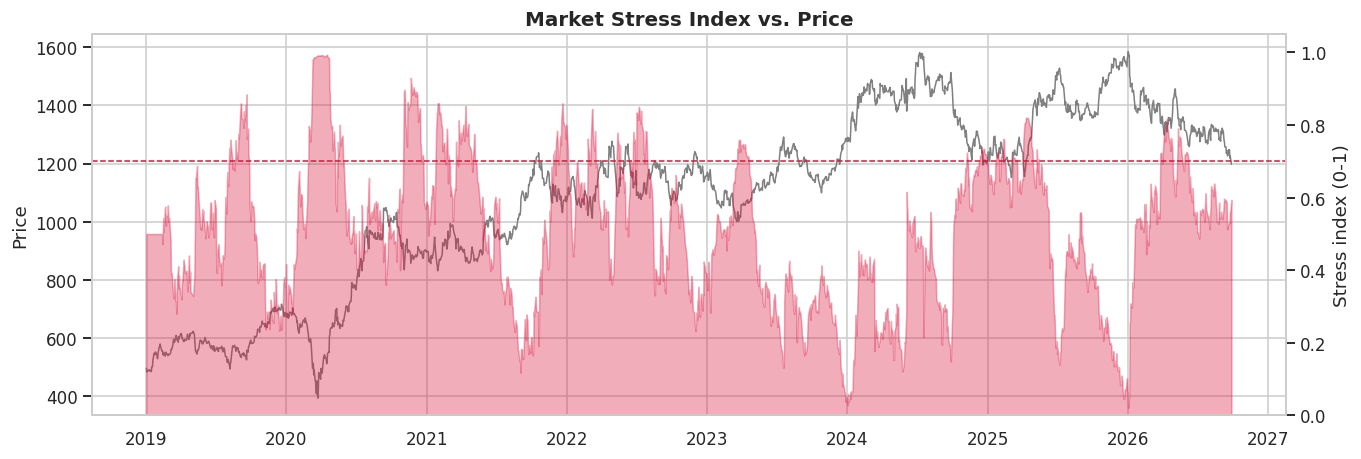

In [ ]:
vol_pct = rv.rank(pct=True).reindex(price.index)
dd_pct  = (-dd).rank(pct=True)
w = STRESS_WEIGHTS
stress = (w["volatility"]*vol_pct + w["drawdown"]*dd_pct)/(w["volatility"]+w["drawdown"])
stress = stress.fillna(0.5)
stress_daily = stress.reindex(pd.date_range(MKT_START, OBS_END, freq="D")).ffill().bfill()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(price.index, price.values, color="gray", lw=1, label="Price")
ax.set_ylabel("Price")
ax2 = ax.twinx(); ax2.grid(False)
ax2.fill_between(stress.index, stress.values, color="crimson", alpha=.35, label="Stress index")
ax2.axhline(.7, color="crimson", ls="--", lw=1); ax2.set_ylim(0, 1.05); ax2.set_ylabel("Stress index (0-1)")
ax.set_title("Market Stress Index vs. Price")
plt.show()
explain("How to read this", "Red shaded area = stress level. When the red climbs above the dashed line (0.7) markets are in <b>high-stress</b> mode "
        "– usually when prices are falling fast and swings are large. Hedge-fund investors often pause or redeem in such periods.")

## 3️⃣ Corporate Bankruptcy Risk – Altman Z-Score
A famous formula (Edward Altman, 1968) that combines 5 financial ratios into one health score:

* **Z > 2.99 → 🟢 Safe zone**  • **1.81 – 2.99 → 🟡 Grey zone**  • **Z < 1.81 → 🔴 Distress zone**

Useful for **M&A** (screening acquisition targets / counterparties) and **hedge funds** (avoiding fragile stocks).
⚠️ Not meaningful for banks/insurers (their balance sheets work differently).

Company,Z-Score,Zone,Illustrative distress score
RELIANCE.NS,1.910000,🟡 Grey,45%
TCS.NS,9.900000,🟢 Safe,0%
INFY.NS,377.220000,🟢 Safe,0%
ITC.NS,12.560000,🟢 Safe,0%


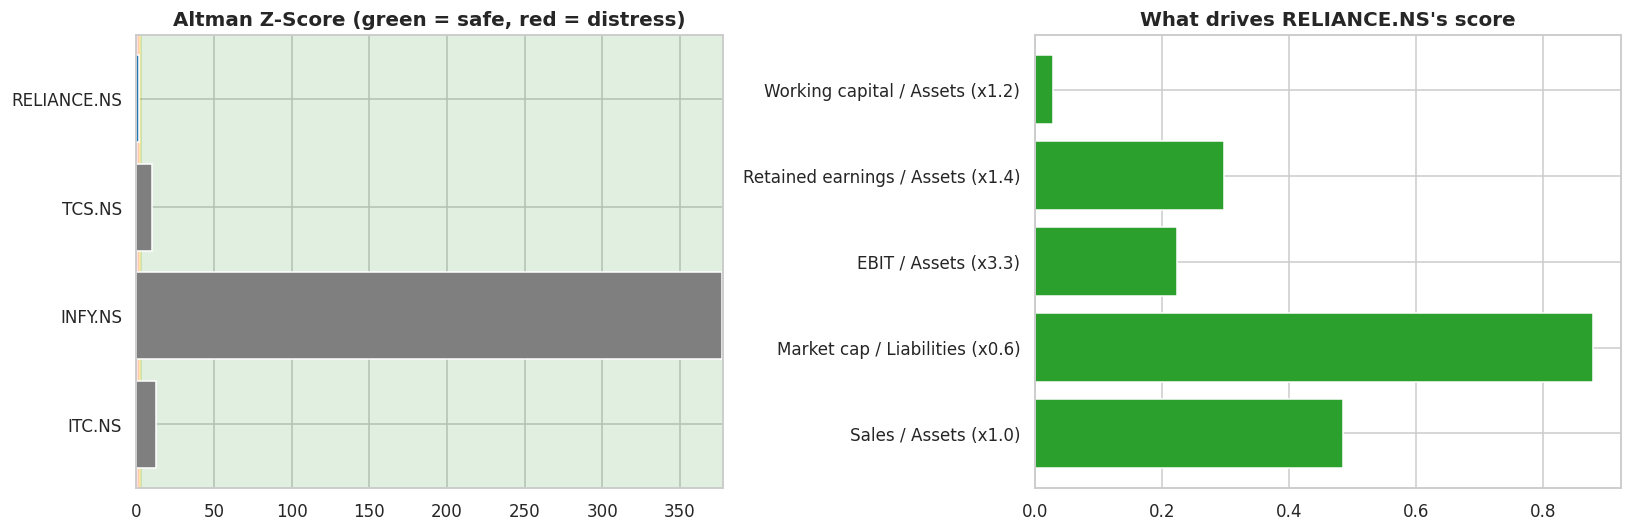

In [ ]:
def altman_z(sym):
    try:
        t = yf.Ticker(sym)
        bs, inc = t.balance_sheet, t.financials
        def pick(df, names):
            for n in names:
                if n in df.index:
                    v = df.loc[n].dropna()
                    if len(v): return float(v.iloc[0])
            return np.nan
        TA   = pick(bs,  ["Total Assets"])
        CA   = pick(bs,  ["Current Assets", "Total Current Assets"])
        CL   = pick(bs,  ["Current Liabilities", "Total Current Liabilities"])
        RE   = pick(bs,  ["Retained Earnings"])
        TL   = pick(bs,  ["Total Liabilities Net Minority Interest", "Total Liab", "Total Liabilities"])
        EBIT = pick(inc, ["EBIT", "Operating Income"])
        REV  = pick(inc, ["Total Revenue", "Operating Revenue"])
        mcap = np.nan
        try: mcap = float(t.fast_info["market_cap"])
        except Exception:
            try: mcap = float(t.info.get("marketCap", np.nan))
            except Exception: pass
        if np.isnan(RE): RE = 0.0
        need = dict(TA=TA, CA=CA, CL=CL, TL=TL, EBIT=EBIT, REV=REV, MCAP=mcap)
        missing = [k for k, v in need.items() if np.isnan(v)]
        if missing: raise ValueError(f"missing data: {missing}")
        comp = {"Working capital / Assets (x1.2)":   1.2*(CA-CL)/TA,
                "Retained earnings / Assets (x1.4)": 1.4*RE/TA,
                "EBIT / Assets (x3.3)":              3.3*EBIT/TA,
                "Market cap / Liabilities (x0.6)":   0.6*mcap/TL,
                "Sales / Assets (x1.0)":             1.0*REV/TA}
        z = sum(comp.values())
        return dict(ticker=sym, z=z, comp=comp)
    except Exception as e:
        print(f"⚠️  Altman Z skipped for {sym}: {e}")
        return None

results = [r for r in (altman_z(s) for s in [TICKER] + list(PEER_TICKERS)) if r]
if results:
    zdf = pd.DataFrame([{"Company": r["ticker"], "Z-Score": round(r["z"], 2),
                         "Zone": "🟢 Safe" if r["z"] > 2.99 else ("🟡 Grey" if r["z"] > 1.81 else "🔴 Distress"),
                         "Illustrative distress score": f"{1/(1+np.exp(2*(r['z']-1.81))):.0%}"} for r in results])
    display(zdf.style.hide(axis="index"))

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    zs = [r["z"] for r in results]; names = [r["ticker"] for r in results]
    xmax = max(4, max(zs)+.5); xmin = min(0, min(zs)-.5)
    ax[0].axvspan(xmin, 1.81, color="red", alpha=.12); ax[0].axvspan(1.81, 2.99, color="gold", alpha=.18); ax[0].axvspan(2.99, xmax, color="green", alpha=.12)
    ax[0].barh(names, zs, color=["#1f77b4"]+["#7f7f7f"]*(len(zs)-1)); ax[0].set_xlim(xmin, xmax)
    ax[0].set_title("Altman Z-Score (green = safe, red = distress)"); ax[0].invert_yaxis()
    main = results[0]
    ax[1].barh(list(main["comp"].keys()), list(main["comp"].values()), color="#2ca02c")
    ax[1].set_title(f"What drives {main['ticker']}'s score"); ax[1].invert_yaxis()
    plt.tight_layout(); plt.show()
    explain("How to read this",
            "<b>Left:</b> each bar is a company's health score – the further right (green zone), the safer. Bars in the red zone signal elevated bankruptcy risk. "
            "<b>Right:</b> shows which ingredients push your main company's score up (profits, assets, growth) so you know <i>why</i> it scores high or low. "
            "The 'illustrative distress score' is a rough teaching conversion, not a true probability of default.")
else:
    print("ℹ️ No fundamentals available right now – skipping bankruptcy section (the rest of the notebook is unaffected).")

## 4️⃣ Client Data: Demographics + Time-Stamped Transactions
Each client has demographics (age, wealth, region…) and a stream of dated transactions (revenue earned by the firm: subscriptions, advisory fees, commissions).
The simulation makes clients **less active when your ticker's Market Stress Index is high**, so market risk genuinely flows into CLV.

In [ ]:
def simulate_data(n, seed):
    rng = np.random.default_rng(seed)
    span = (OBS_END - MKT_START).days
    segs = list(SEGMENT_SETTINGS); pr = np.array([SEGMENT_SETTINGS[s]["p"] for s in segs]); pr = pr/pr.sum()
    seg     = rng.choice(segs, n, p=pr)
    income  = rng.choice(["Mass Affluent", "HNI", "UHNI", "Institutional"], n, p=[.35, .40, .20, .05])
    channel = rng.choice(["Referral", "Advisor", "Digital", "Event"], n, p=[.25, .30, .30, .15])
    risk    = rng.choice(["Conservative", "Balanced", "Aggressive"], n, p=[.30, .45, .25])
    region  = rng.choice(["Mumbai", "Delhi", "Bengaluru", "Singapore", "London", "New York"], n, p=[.30, .15, .15, .15, .13, .12])
    age     = np.clip(rng.normal(46, 11, n), 25, 78).round().astype(int)
    signup_day = rng.integers(0, max(span-60, 100), n)

    wealth = pd.Series(income).map({"Mass Affluent": .6, "HNI": 1.0, "UHNI": 2.5, "Institutional": 6.0}).values
    ch_life = pd.Series(channel).map({"Referral": 1.3, "Advisor": 1.1, "Digital": .8, "Event": .9}).values
    rk_gap  = pd.Series(risk).map({"Conservative": 1.4, "Balanced": 1.0, "Aggressive": .7}).values
    ticket = np.array([SEGMENT_SETTINGS[s]["ticket"] for s in seg])*wealth*rng.lognormal(0, .35, n)
    gap    = np.array([SEGMENT_SETTINGS[s]["gap"] for s in seg])*rk_gap*rng.lognormal(0, .30, n)
    life   = np.array([SEGMENT_SETTINGS[s]["life"] for s in seg])*ch_life*np.exp(.01*(age-46))*rng.weibull(1.3, n)

    stress_arr = stress_daily.values
    rows = []
    for i in range(n):
        t, end_day = float(signup_day[i]), min(signup_day[i] + life[i], span)
        first = True
        while t <= end_day:
            st = stress_arr[min(int(t), len(stress_arr)-1)]
            keep = first or rng.random() < np.clip(1 - MARKET_STRESS_IMPACT*(st-.5), .25, 1.0)
            if keep:
                amt = ticket[i]*rng.lognormal(0, .5)*(1 - .3*MARKET_STRESS_IMPACT*(st-.5))
                rows.append((i, int(t), amt, st))
            first = False
            t += max(1.0, rng.exponential(gap[i]))
    tx = pd.DataFrame(rows, columns=["cid", "day", "amount", "stress"])
    tx["customer_id"] = "C" + tx["cid"].astype(str).str.zfill(5)
    tx["date"] = MKT_START + pd.to_timedelta(tx["day"], unit="D")
    cust = pd.DataFrame({"customer_id": ["C"+str(i).zfill(5) for i in range(n)],
                         "signup_date": MKT_START + pd.to_timedelta(signup_day, unit="D"),
                         "age": age, "income_band": income, "region": region,
                         "channel": channel, "risk_appetite": risk, "segment": seg})
    return cust, tx[["customer_id", "date", "amount", "stress"]]

if CUSTOMERS_CSV and TRANSACTIONS_CSV:
    cust = pd.read_csv(CUSTOMERS_CSV, parse_dates=["signup_date"])
    txns = pd.read_csv(TRANSACTIONS_CSV, parse_dates=["date"])
    txns = txns[txns.date <= OBS_END].copy()
    txns["stress"] = stress_daily.reindex(txns["date"].dt.normalize()).values
    txns["stress"] = txns["stress"].fillna(.5)
    print("📂 Loaded your own client data.")
else:
    cust, txns = simulate_data(N_CUSTOMERS, RANDOM_STATE)
    print("🧪 Simulated client data created.")

cust["signup_date"] = pd.to_datetime(cust["signup_date"]).dt.normalize()
txns["date"] = pd.to_datetime(txns["date"]).dt.normalize()
SEGMENT_COL = "segment" if "segment" in cust.columns else cust.select_dtypes("object").columns.drop("customer_id", errors="ignore")[0]
print(f"Clients: {len(cust):,}   |   Transactions: {len(txns):,}   |   Total revenue: {money(txns.amount.sum())}")
display(cust.head(5)); display(txns.head(5))

🧪 Simulated client data created.
Clients: 3,000   |   Transactions: 67,732   |   Total revenue: ₹3,225,927,019


,customer_id,signup_date,age,income_band,region,channel,risk_appetite,segment
0,C00000,2021-03-12,62,UHNI,Bengaluru,Advisor,Aggressive,Structured Products
1,C00001,2020-09-15,65,HNI,Delhi,Referral,Conservative,Hedge Fund LP
2,C00002,2021-06-03,50,Mass Affluent,Mumbai,Digital,Balanced,Structured Products
3,C00003,2025-09-15,32,HNI,New York,Referral,Conservative,Structured Products
4,C00004,2022-07-08,65,Mass Affluent,Mumbai,Referral,Conservative,Hedge Fund LP


,customer_id,date,amount,stress
0,C00000,2021-03-12,20523.261890,0.598402
1,C00000,2021-03-24,16121.302780,0.741902
2,C00000,2021-03-27,24409.761324,0.784184
3,C00000,2021-04-19,24745.228057,0.803169
4,C00000,2021-06-05,37213.938744,0.478211


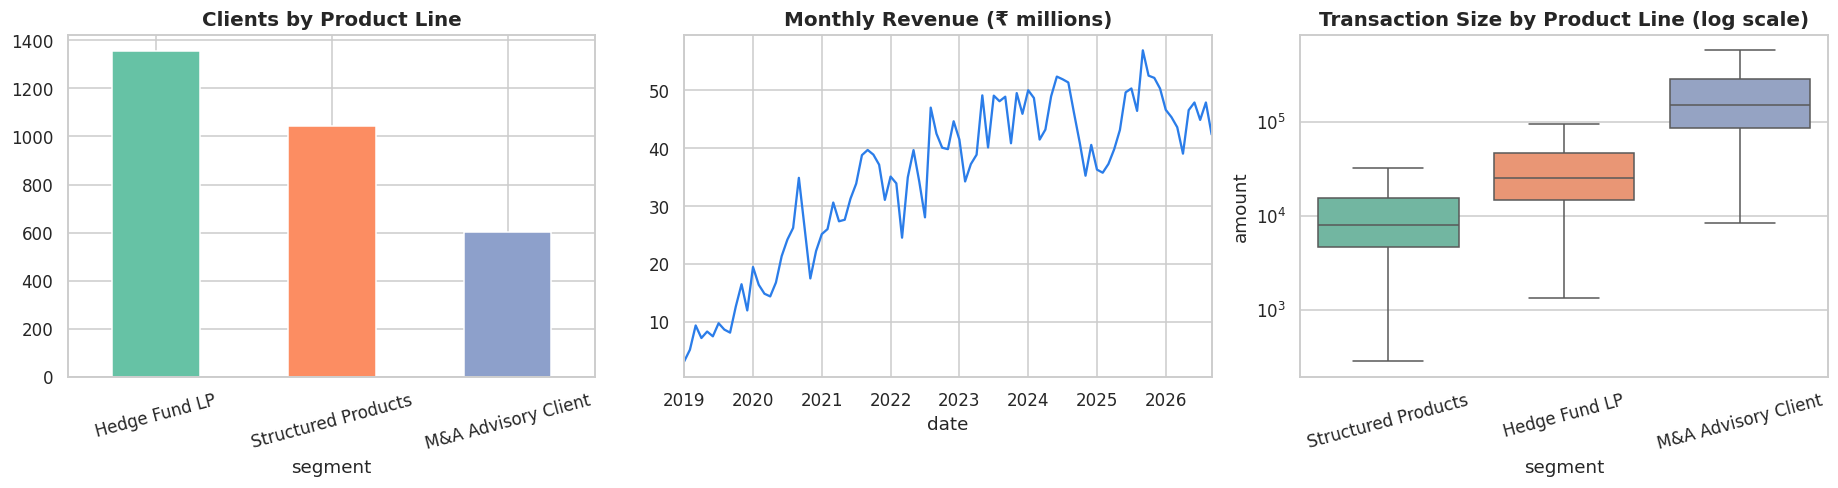

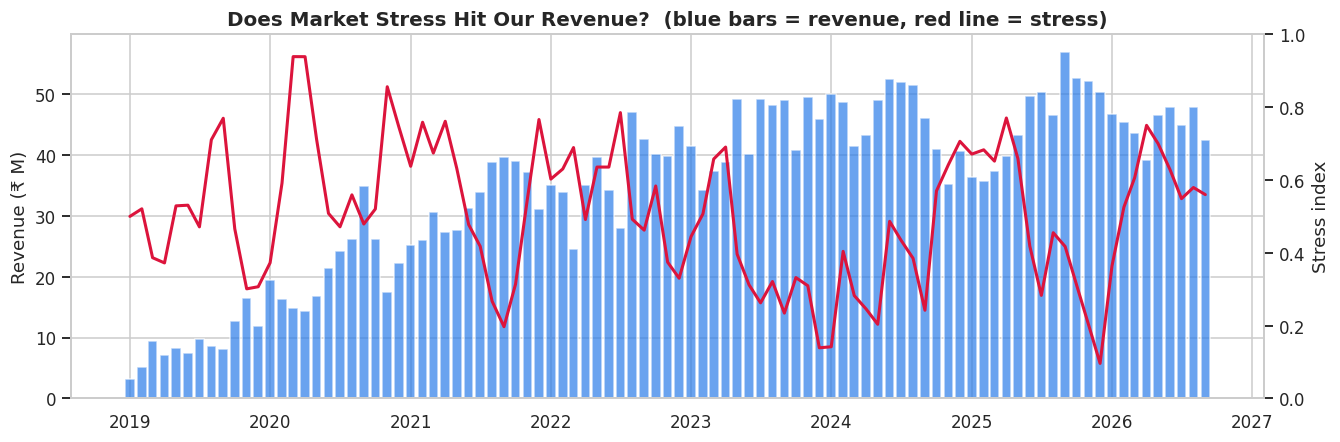

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
cust[SEGMENT_COL].value_counts().plot.bar(ax=ax[0], color=sns.color_palette("Set2")); ax[0].set_title("Clients by Product Line"); ax[0].tick_params(axis="x", rotation=15)
txns.groupby(txns.date.dt.to_period("M"))["amount"].sum().div(1e6).plot(ax=ax[1], color="#2b7de9"); ax[1].set_title(f"Monthly Revenue ({CURRENCY} millions)")
sns.boxplot(data=txns.merge(cust[["customer_id", SEGMENT_COL]]), x=SEGMENT_COL, y="amount", ax=ax[2], showfliers=False, palette="Set2")
ax[2].set_yscale("log"); ax[2].set_title("Transaction Size by Product Line (log scale)"); ax[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
explain("How to read this", "<b>Left:</b> how many clients each product has. <b>Middle:</b> total money earned each month – dips often line up with market stress. "
        "<b>Right:</b> typical size of one transaction; M&A deals are rarer but much bigger (log scale makes small & big comparable).")

# Market ↔ revenue link
m_rev = txns.groupby(txns.date.dt.to_period("M"))["amount"].sum()
m_str = stress_daily.groupby(stress_daily.index.to_period("M")).mean().reindex(m_rev.index)
fig, ax = plt.subplots(figsize=(14, 4.3))
ax.bar(m_rev.index.to_timestamp(), m_rev.values/1e6, width=25, color="#2b7de9", alpha=.7, label="Revenue")
ax.set_ylabel(f"Revenue ({CURRENCY} M)")
ax2 = ax.twinx(); ax2.plot(m_str.index.to_timestamp(), m_str.values, color="crimson", lw=2, label="Market stress"); ax2.set_ylim(0, 1); ax2.grid(False); ax2.set_ylabel("Stress index")
ax.set_title("Does Market Stress Hit Our Revenue?  (blue bars = revenue, red line = stress)")
plt.show()
explain("How to read this", "If red peaks sit above smaller blue bars, revenue is falling when stress is high. Revenue also grows/shrinks simply because the client base grows and churns – "
        "so use this chart for direction, not exact cause.")

## 5️⃣ Cohort Analysis
A **cohort** = all clients who joined in the same quarter. We track what share of each cohort is still transacting as time passes.

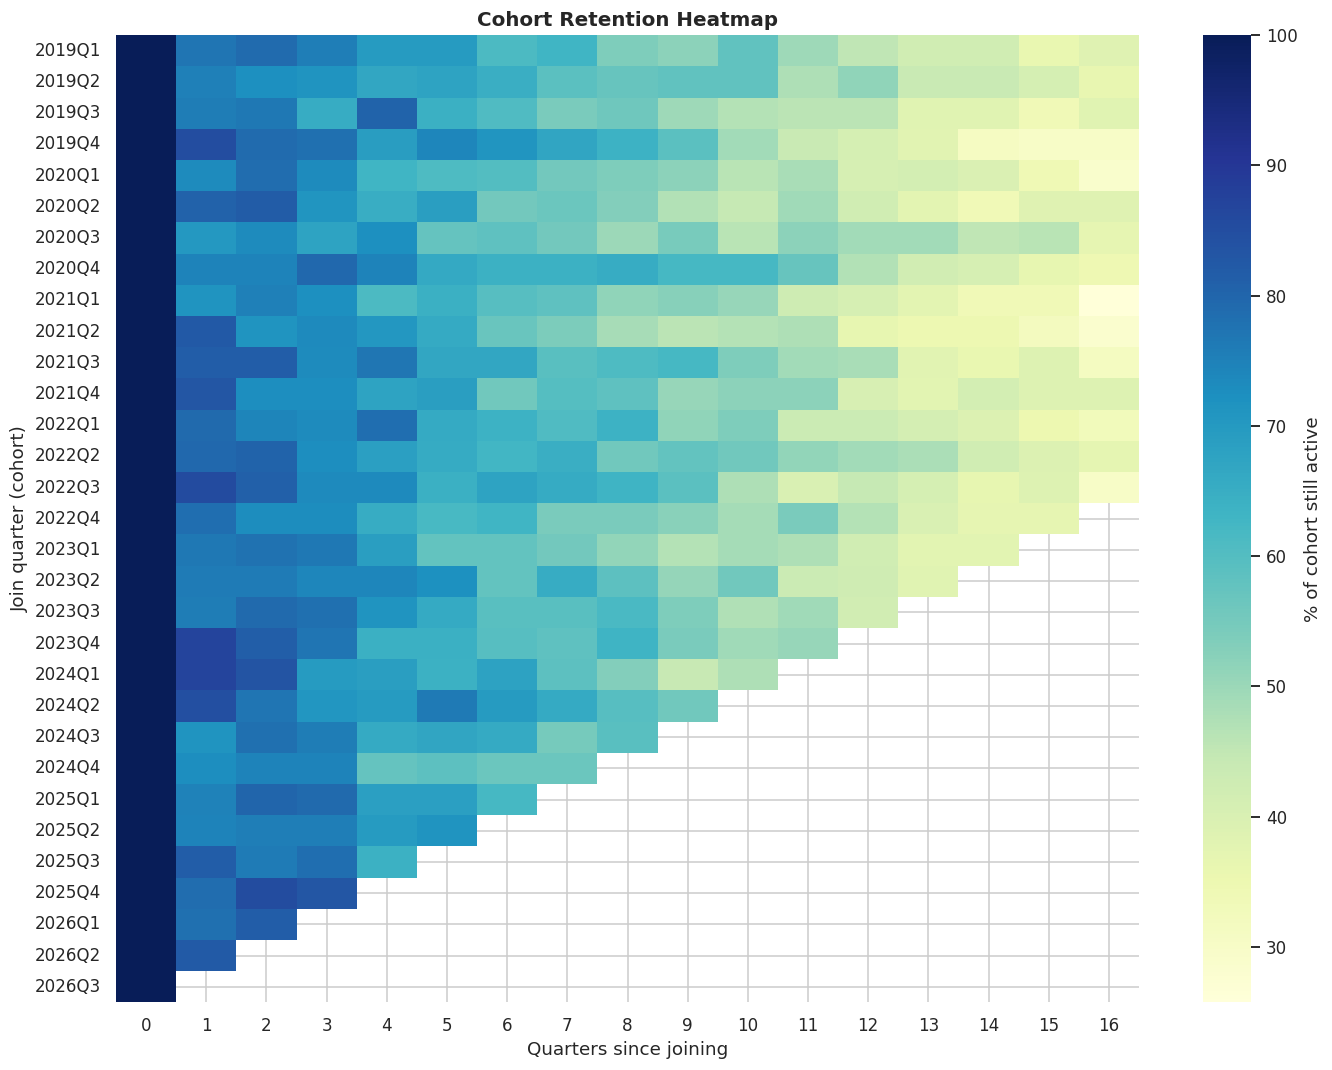

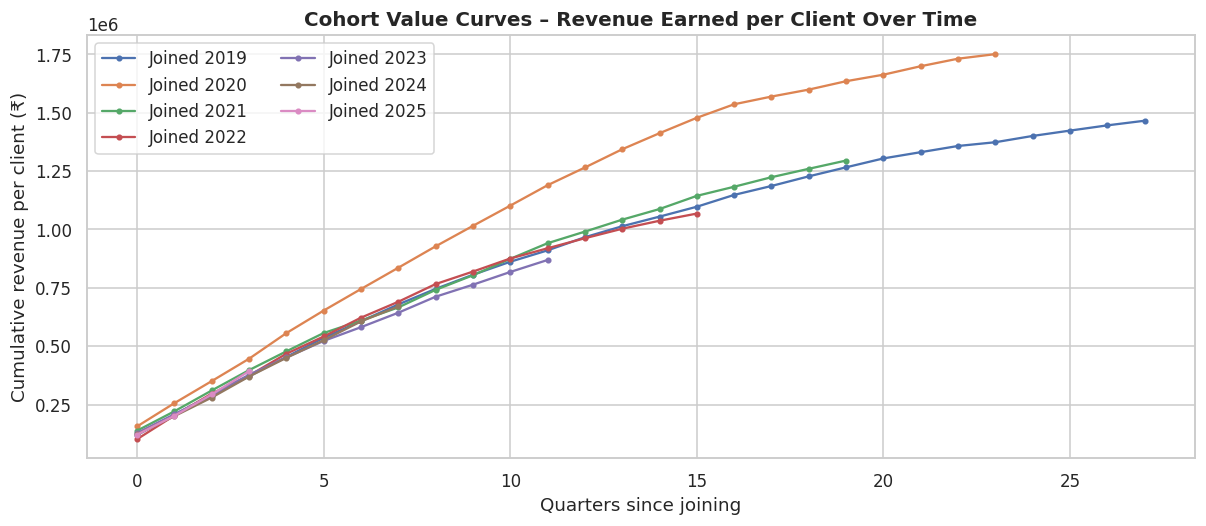

In [ ]:
tx = txns.merge(cust[["customer_id", "signup_date"]], on="customer_id")
tx["cohort"]  = tx["signup_date"].dt.to_period("Q")
tx["q_since"] = (tx.date.dt.year-tx.signup_date.dt.year)*4 + (tx.date.dt.quarter-tx.signup_date.dt.quarter)
cust["cohort"] = cust["signup_date"].dt.to_period("Q")
csize = cust.groupby("cohort").size()

act = tx.groupby(["cohort", "q_since"])["customer_id"].nunique().unstack(fill_value=0)
retention = act.div(csize.reindex(act.index), axis=0).iloc[:, :17]
mask = np.zeros(retention.shape, bool)
for i, c in enumerate(retention.index):
    max_q = (OBS_END.year-c.year)*4 + (OBS_END.quarter-c.quarter)
    for j, q in enumerate(retention.columns):
        mask[i, j] = q > max_q
retention = retention[csize.reindex(retention.index) >= 10]
mask = mask[[list(act.index).index(c) for c in retention.index]]

fig, ax = plt.subplots(figsize=(15, max(5, .32*len(retention)+1.5)))
sns.heatmap(retention*100, mask=mask, cmap="YlGnBu", ax=ax, annot=len(retention) <= 14, fmt=".0f", cbar_kws={"label": "% of cohort still active"})
ax.set_yticklabels([str(c) for c in retention.index], rotation=0)
ax.set_xlabel("Quarters since joining"); ax.set_ylabel("Join quarter (cohort)"); ax.set_title("Cohort Retention Heatmap")
plt.show()
explain("How to read this", "Each row = clients who joined in that quarter. Moving <b>right</b> shows time passing. Dark blue = most of the group is still active; pale = many have left. "
        "A row that fades faster than the others = a weaker cohort (worse onboarding, market conditions, or client mix). Blank cells = the future (not observed yet).")

# cumulative revenue per client by signup year
tx["year"] = tx.signup_date.dt.year
ysize = cust.groupby(cust.signup_date.dt.year).size()
rev = tx.groupby(["year", "q_since"])["amount"].sum().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13, 5))
for y in rev.index:
    lim = (OBS_END.year-y)*4 + OBS_END.quarter - 4
    if lim <= 0 or ysize[y] < 20: continue
    s = (rev.loc[y].reindex(range(0, lim+1), fill_value=0)/ysize[y]).cumsum()
    ax.plot(s.index, s.values, marker="o", ms=3, label=f"Joined {y}")
ax.set_xlabel("Quarters since joining"); ax.set_ylabel(f"Cumulative revenue per client ({CURRENCY})"); ax.set_title("Cohort Value Curves – Revenue Earned per Client Over Time"); ax.legend(ncol=2)
plt.show()
explain("How to read this", "Each line follows one year's new clients. The higher & steeper the line, the more money the average client from that year has produced so far – "
        "this is 'realised CLV' to date. Flattening lines mean clients are becoming inactive.")

## 6️⃣ Feature Engineering from Time-Stamped Data
To avoid "peeking into the future", we pick a **snapshot date** = *last date − prediction horizon*.

* Everything **before** the snapshot → features (RFM, gaps, trends, market-stress behaviour…)
* Revenue **after** the snapshot (next N days) → the target we want to predict

In [ ]:
SNAPSHOT = OBS_END - pd.Timedelta(days=CLV_HORIZON_DAYS)
print(f"📅 Snapshot date: {SNAPSHOT.date()}   →   predicting revenue from {SNAPSHOT.date()} to {OBS_END.date()}")

def build_features(cust, txns, snap):
    t = txns[txns.date <= snap].sort_values(["customer_id", "date"]).copy()
    t["gap"] = t.groupby("customer_id")["date"].diff().dt.days
    t["is_q4"] = (t.date.dt.quarter == 4).astype(int)
    t["high_stress"] = (t["stress"] > .7).astype(int)
    g = t.groupby("customer_id")
    f = pd.DataFrame({
        "frequency": g.size(), "monetary_total": g["amount"].sum(), "monetary_avg": g["amount"].mean(),
        "monetary_max": g["amount"].max(), "monetary_std": g["amount"].std(),
        "avg_gap_days": g["gap"].mean(), "gap_std_days": g["gap"].std(), "max_gap_days": g["gap"].max(),
        "q4_share": g["is_q4"].mean(),                       # seasonality
        "avg_market_stress_at_txn": g["stress"].mean(),      # market regime when client trades
        "share_txn_in_high_stress": g["high_stress"].mean(), # does client trade in turbulent markets?
        "last_txn": g["date"].max(), "first_txn": g["date"].min()})
    for label, lo, hi in [("last90", 0, 90), ("prev90", 90, 180)]:
        w = t[(t.date > snap - pd.Timedelta(days=hi)) & (t.date <= snap - pd.Timedelta(days=lo))]
        f[f"txn_{label}"] = w.groupby("customer_id").size()
        f[f"amt_{label}"] = w.groupby("customer_id")["amount"].sum()
    f = cust.drop(columns=["cohort"], errors="ignore").set_index("customer_id").join(f, how="inner")
    f["recency_days"] = (snap - f.last_txn).dt.days
    f["tenure_days"]  = (snap - f.signup_date).dt.days
    f["txn_per_month"] = f.frequency/(f.tenure_days/30.44 + 1)
    for c in ["txn_last90", "amt_last90", "txn_prev90", "amt_prev90", "monetary_std", "gap_std_days"]: f[c] = f[c].fillna(0)
    f["spend_trend"]   = (f.amt_last90 + 1)/(f.amt_prev90 + 1)     # >1 = client is spending more recently
    f["avg_gap_days"] = f["avg_gap_days"].fillna(f["tenure_days"]); f["max_gap_days"] = f["max_gap_days"].fillna(f["tenure_days"])
    return f

feats = build_features(cust, txns, SNAPSHOT)
pop = feats[feats.signup_date <= SNAPSHOT - pd.Timedelta(days=MIN_HISTORY_DAYS)].copy()

future = txns[(txns.date > SNAPSHOT) & (txns.date <= SNAPSHOT + pd.Timedelta(days=CLV_HORIZON_DAYS))].groupby("customer_id")["amount"].sum()
pop["future_clv"] = future.reindex(pop.index).fillna(0.0)
pop["churned"] = (pop.recency_days > CHURN_INACTIVITY_DAYS).astype(int)
print(f"Modeling population: {len(pop):,} clients  |  Already inactive (churned): {pop.churned.mean():.1%}  |  "
      f"Avg future {CLV_HORIZON_DAYS}-day revenue: {money(pop.future_clv.mean())}  |  Zero-revenue clients: {(pop.future_clv==0).mean():.1%}")
display(pop.drop(columns=["signup_date", "last_txn", "first_txn"]).head(5).round(2))

📅 Snapshot date: 2025-09-28   →   predicting revenue from 2025-09-28 to 2026-09-28
Modeling population: 2,608 clients  |  Already inactive (churned): 44.2%  |  Avg future 365-day revenue: ₹169,469  |  Zero-revenue clients: 51.4%


,age,income_band,region,channel,risk_appetite,segment,frequency,monetary_total,monetary_avg,monetary_max,...,txn_last90,amt_last90,txn_prev90,amt_prev90,recency_days,tenure_days,txn_per_month,spend_trend,future_clv,churned
customer_id,,,,,,,,,,,,,,,,,,,,,
C00000,62,UHNI,Bengaluru,Advisor,Aggressive,Structured Products,18,536406.57,29800.37,84742.57,...,0.0,0.00,0.0,0.00,1330,1661,0.32,1.00,0.00,1
C00001,65,HNI,Delhi,Referral,Conservative,Hedge Fund LP,39,697150.66,17875.66,48057.49,...,2.0,23032.82,3.0,45501.73,24,1839,0.64,0.51,85958.82,0
C00002,50,Mass Affluent,Mumbai,Digital,Balanced,Structured Products,48,369708.99,7702.27,27180.59,...,0.0,0.00,0.0,0.00,599,1578,0.91,1.00,0.00,1
C00004,65,Mass Affluent,Mumbai,Referral,Conservative,Hedge Fund LP,23,314428.31,13670.80,28153.26,...,1.0,10205.80,0.0,0.00,79,1178,0.58,10206.80,56920.64,0
C00005,35,UHNI,Mumbai,Advisor,Balanced,Structured Products,57,2594555.35,45518.51,148702.60,...,4.0,143532.31,5.0,157227.23,21,1301,1.30,0.91,637533.74,0


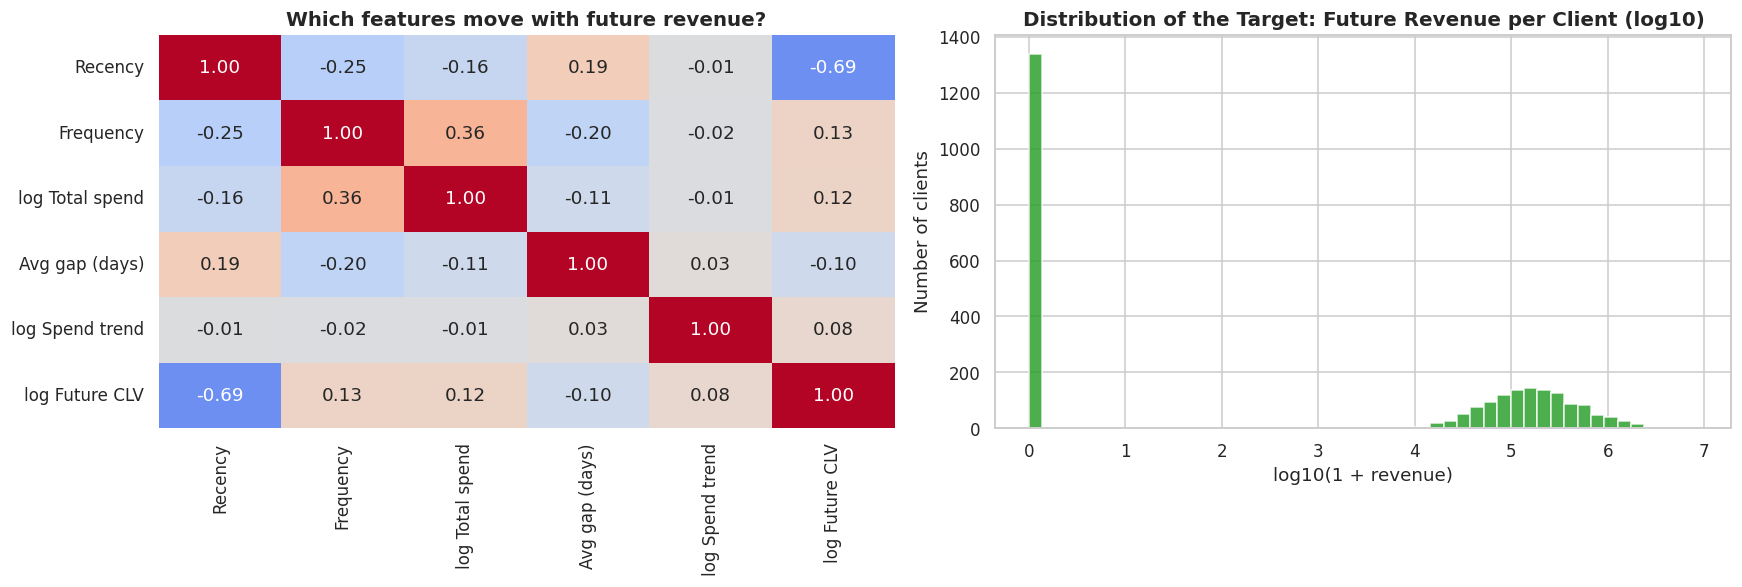

In [ ]:
num_view = pop[["recency_days", "frequency", "monetary_total", "avg_gap_days", "spend_trend", "future_clv"]].copy()
num_view["monetary_total"] = np.log10(num_view.monetary_total+1); num_view["future_clv"] = np.log10(num_view.future_clv+1)
num_view["spend_trend"] = np.log10(num_view.spend_trend)
num_view.columns = ["Recency", "Frequency", "log Total spend", "Avg gap (days)", "log Spend trend", "log Future CLV"]
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
sns.heatmap(num_view.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0], cbar=False); ax[0].set_title("Which features move with future revenue?")
ax[1].hist(np.log10(pop.future_clv+1), bins=50, color="#2ca02c", alpha=.85)
ax[1].set_title("Distribution of the Target: Future Revenue per Client (log10)"); ax[1].set_xlabel("log10(1 + revenue)"); ax[1].set_ylabel("Number of clients")
plt.tight_layout(); plt.show()
explain("How to read this", "<b>Left:</b> red = two things rise together, blue = one rises while the other falls. Look at the last row: strong red on Frequency/Total spend means past "
        "behaviour predicts future value; blue on Recency means clients who went quiet recently are worth less. "
        "<b>Right:</b> the big bar at far left = clients who bring nothing next year (churners). We use a log scale because a few clients bring huge sums.")

## 7️⃣ Survival Modeling – *How long will a client stay?*
* **Kaplan-Meier** curve = the share of clients still "alive" (active) after X months.
* **Cox regression** = tells which client traits **speed up or slow down** leaving (hazard ratios).
* Clients still active are **censored** (we know they lasted *at least* this long) – survival models handle this properly, plain regression cannot.

Cox uses only info known **early** (demographics + first 90 days), so it can score any client.

In [ ]:
surv = pop[["signup_date", "last_txn", "tenure_days", "churned"]].copy()
surv["duration"] = np.where(surv.churned == 1, (surv.last_txn - surv.signup_date).dt.days, surv.tenure_days).clip(min=1)
surv["event"] = surv.churned
surv["duration_m"] = surv.duration/30.44

# early-behaviour covariates (first 90 days after signup)
ts = txns.merge(cust[["customer_id", "signup_date"]], on="customer_id")
early = ts[(ts.date - ts.signup_date).dt.days <= 90].groupby("customer_id")["amount"].agg(early_txn_count="size", early_amount="sum")
demo_cols = [c for c in cust.columns if c not in ("customer_id", "signup_date", "cohort")]
cox_X = pop[demo_cols].copy().join(early).fillna({"early_txn_count": 0, "early_amount": 0})
cox_X["early_amount"] = np.log1p(cox_X["early_amount"])
cat = cox_X.select_dtypes(include=["object", "category"]).columns
cox_X = pd.get_dummies(cox_X, columns=list(cat), drop_first=True, dtype=float)
cox_X = cox_X.loc[:, cox_X.std() > 0]
cox_X = (cox_X - cox_X.mean())/cox_X.std()          # standardise so hazard ratios are "per 1 std-dev"

cox_df = cox_X.join(surv[["duration", "event"]])
cph = CoxPHFitter(penalizer=COX_PENALIZER)
cph.fit(cox_df, duration_col="duration", event_col="event")
print(f"Cox model concordance (C-index): {cph.concordance_index_:.3f}   (0.5 = coin flip, 1.0 = perfect ranking; >0.65 is useful)")

Cox model concordance (C-index): 0.612   (0.5 = coin flip, 1.0 = perfect ranking; >0.65 is useful)


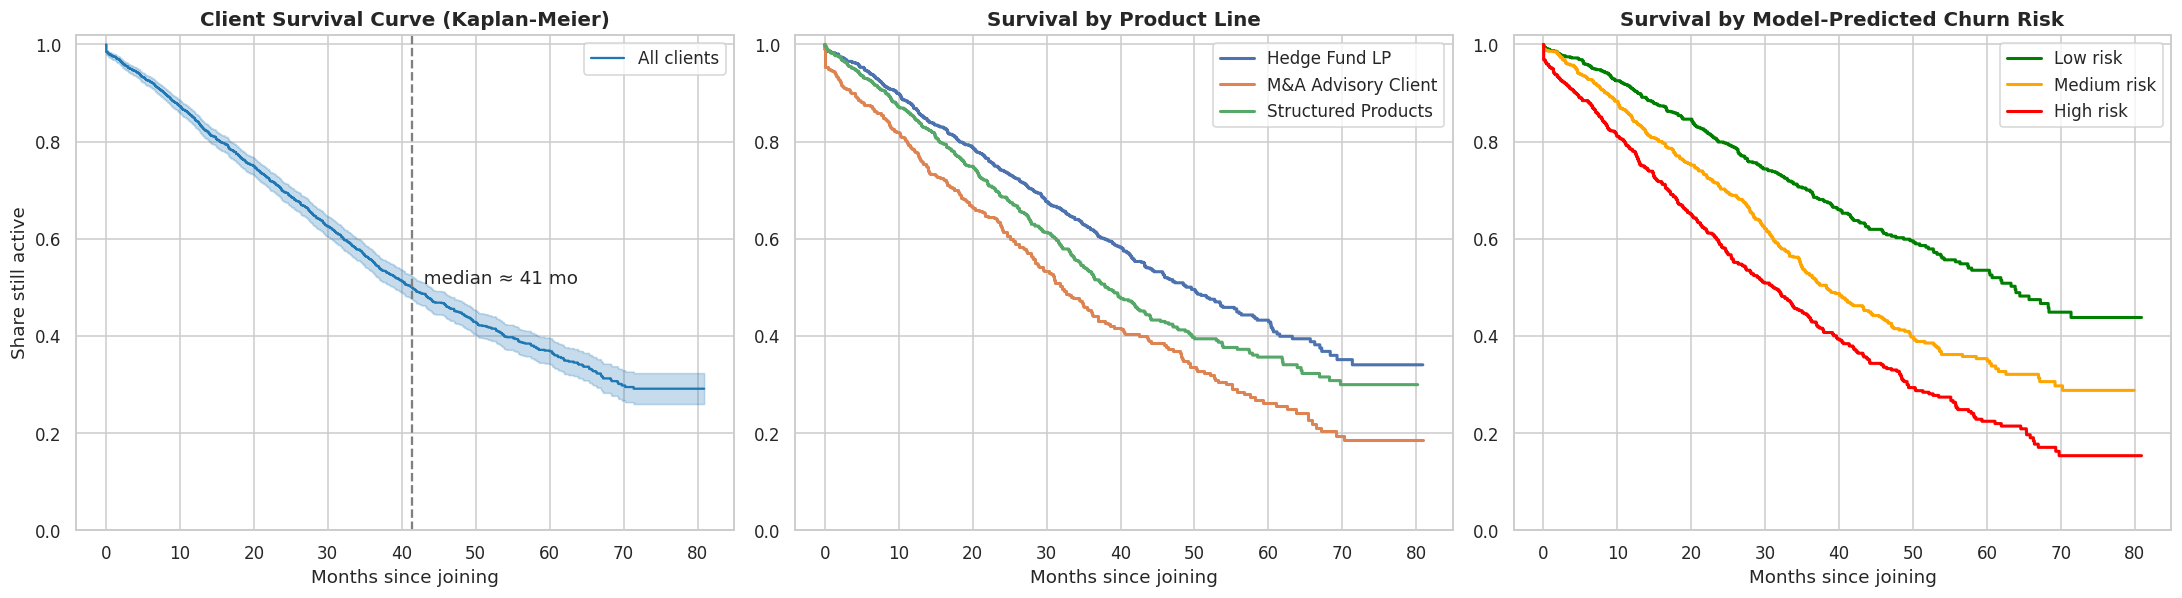

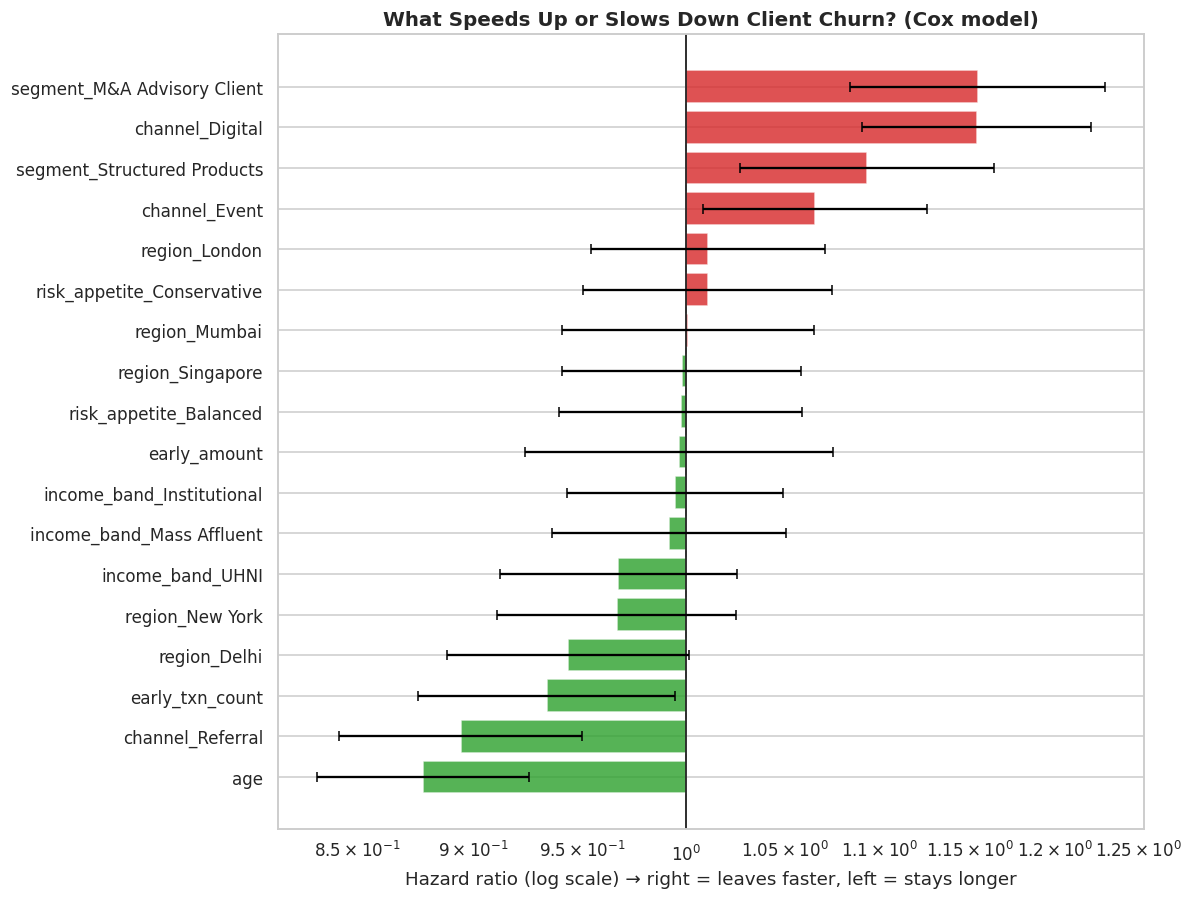

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5.6))

# (a) overall KM
km = KaplanMeierFitter().fit(surv.duration_m, surv.event, label="All clients")
km.plot_survival_function(ax=ax[0], color="#1f77b4"); ax[0].set_ylim(0, 1.02)
ax[0].set_title("Client Survival Curve (Kaplan-Meier)"); ax[0].set_xlabel("Months since joining"); ax[0].set_ylabel("Share still active")
med = km.median_survival_time_
if np.isfinite(med): ax[0].axvline(med, ls="--", c="gray"); ax[0].text(med, .5, f"  median ≈ {med:.0f} mo", va="bottom")

# (b) KM by product segment
for name, grp in surv.join(pop[[SEGMENT_COL]]).groupby(SEGMENT_COL):
    KaplanMeierFitter().fit(grp.duration_m, grp.event, label=name).plot_survival_function(ax=ax[1], ci_show=False, lw=2)
ax[1].set_ylim(0, 1.02); ax[1].set_title("Survival by Product Line"); ax[1].set_xlabel("Months since joining")

# (c) KM by Cox risk tertile
ph = cph.predict_partial_hazard(cox_X)
grp = pd.qcut(ph.rank(method="first"), 3, labels=["Low risk", "Medium risk", "High risk"])
for name, colr in zip(["Low risk", "Medium risk", "High risk"], ["green", "orange", "red"]):
    m = grp == name
    KaplanMeierFitter().fit(surv.duration_m[m], surv.event[m], label=name).plot_survival_function(ax=ax[2], ci_show=False, color=colr, lw=2)
ax[2].set_ylim(0, 1.02); ax[2].set_title("Survival by Model-Predicted Churn Risk"); ax[2].set_xlabel("Months since joining")
plt.tight_layout(); plt.show()
explain("How to read these survival curves",
        "A curve starts at 100% (everyone active) and steps down each time clients leave. <b>The higher and flatter the line, the more loyal the clients.</b> "
        "<b>Left:</b> overall loyalty; where it crosses 50% is the median client lifetime. <b>Middle:</b> which product retains best. "
        "<b>Right:</b> a sanity check – if the model works, green (low risk) must sit well above red (high risk). Big gap = good model.")

# hazard-ratio plot
s = cph.summary.sort_values("exp(coef)")
fig, ax = plt.subplots(figsize=(11, max(4, .38*len(s)+1.5)))
colors = ["#d62728" if v > 1 else "#2ca02c" for v in s["exp(coef)"]]
ax.barh(s.index, s["exp(coef)"]-1, left=1, color=colors, alpha=.8)
ax.errorbar(s["exp(coef)"], range(len(s)), xerr=[s["exp(coef)"]-s["exp(coef) lower 95%"], s["exp(coef) upper 95%"]-s["exp(coef)"]], fmt="none", ecolor="black", capsize=3)
ax.axvline(1, color="black", lw=1); ax.set_xscale("log"); ax.set_xlabel("Hazard ratio (log scale) → right = leaves faster, left = stays longer")
ax.set_title("What Speeds Up or Slows Down Client Churn? (Cox model)")
plt.tight_layout(); plt.show()
explain("How to read this", "🔴 Red bars (right of the line) = this trait <b>raises</b> churn risk, 🟢 green bars (left) = trait <b>protects</b> against churn. "
        "A value of 1.3 means '30% higher chance of leaving at any moment' for a 1-std-dev increase (or vs. the baseline category). "
        "Black whiskers = uncertainty: if a whisker crosses the black line at 1, the effect is not statistically clear.")

## 8️⃣ Machine-Learning Regression – Predict 12-Month Client Value
We train a regression model on the engineered features and test it on clients it has **never seen**.
Change `MODEL_CHOICE`, `MODEL_PARAMS`, `LOG_TARGET` or switch on `RUN_TUNING` in the Control Panel.

In [ ]:
drop = ["signup_date", "last_txn", "first_txn", "future_clv"]
X = pop.drop(columns=drop)
catc = X.select_dtypes(include=["object", "category"]).columns
X = pd.get_dummies(X, columns=list(catc), dtype=float).fillna(0)
y = pop["future_clv"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train: {len(X_tr):,} clients | Test: {len(X_te):,} clients | Features: {X.shape[1]}")

MODEL_NAME = MODEL_CHOICE
if MODEL_NAME == "xgboost" and not HAS_XGB:
    print("⚠️ xgboost not available – using GradientBoosting instead."); MODEL_NAME = "gbr"

def make_model(name, params=None):
    p = dict(MODEL_PARAMS[name] if params is None else params)
    if   name == "xgboost": base = XGBRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    elif name == "gbr":     base = GradientBoostingRegressor(**p, random_state=RANDOM_STATE)
    elif name == "rf":      base = RandomForestRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1)
    elif name == "ridge":   base = Pipeline([("scaler", StandardScaler()), ("model", Ridge(**p))])
    else: raise ValueError("MODEL_CHOICE must be xgboost, gbr, rf or ridge")
    return TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1) if LOG_TARGET else base

def evaluate(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred), "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R²": r2_score(y_true, y_pred), "Rank corr (Spearman)": spearmanr(y_true, y_pred)[0]}

# compare all models with the parameters from the Control Panel
names = ["ridge", "rf", "gbr"] + (["xgboost"] if HAS_XGB else [])
scores, fitted = {}, {}
for n in names:
    m = make_model(n).fit(X_tr, y_tr); fitted[n] = m
    scores[n] = evaluate(y_te, np.clip(m.predict(X_te), 0, None))

# optional tuning of the chosen model
if RUN_TUNING:
    prefix = "regressor__" if LOG_TARGET else ""
    grid = {prefix+k: v for k, v in TUNING_GRID[MODEL_NAME].items()}
    search = RandomizedSearchCV(make_model(MODEL_NAME), grid, n_iter=TUNING_N_ITER, cv=TUNING_CV,
                                scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_tr, y_tr)
    print("🔧 Best parameters found:", {k.replace(prefix, ""): v for k, v in search.best_params_.items()})
    fitted[MODEL_NAME+" (tuned)"] = search.best_estimator_
    scores[MODEL_NAME+" (tuned)"] = evaluate(y_te, np.clip(search.best_estimator_.predict(X_te), 0, None))
    FINAL_KEY = MODEL_NAME+" (tuned)"
else:
    FINAL_KEY = MODEL_NAME

model = fitted[FINAL_KEY]
pred_te = np.clip(model.predict(X_te), 0, None)
score_df = pd.DataFrame(scores).T.round(3)
print(f"\n🏆 Selected model: {FINAL_KEY}"); display(score_df)

Train: 1,956 clients | Test: 652 clients | Features: 41

🏆 Selected model: xgboost


,MAE,RMSE,R²,Rank corr (Spearman)
ridge,135728.046,337884.080,0.549,0.656
rf,126739.714,345710.565,0.527,0.726
gbr,133613.925,366503.288,0.469,0.718
xgboost,122162.078,343976.939,0.532,0.736


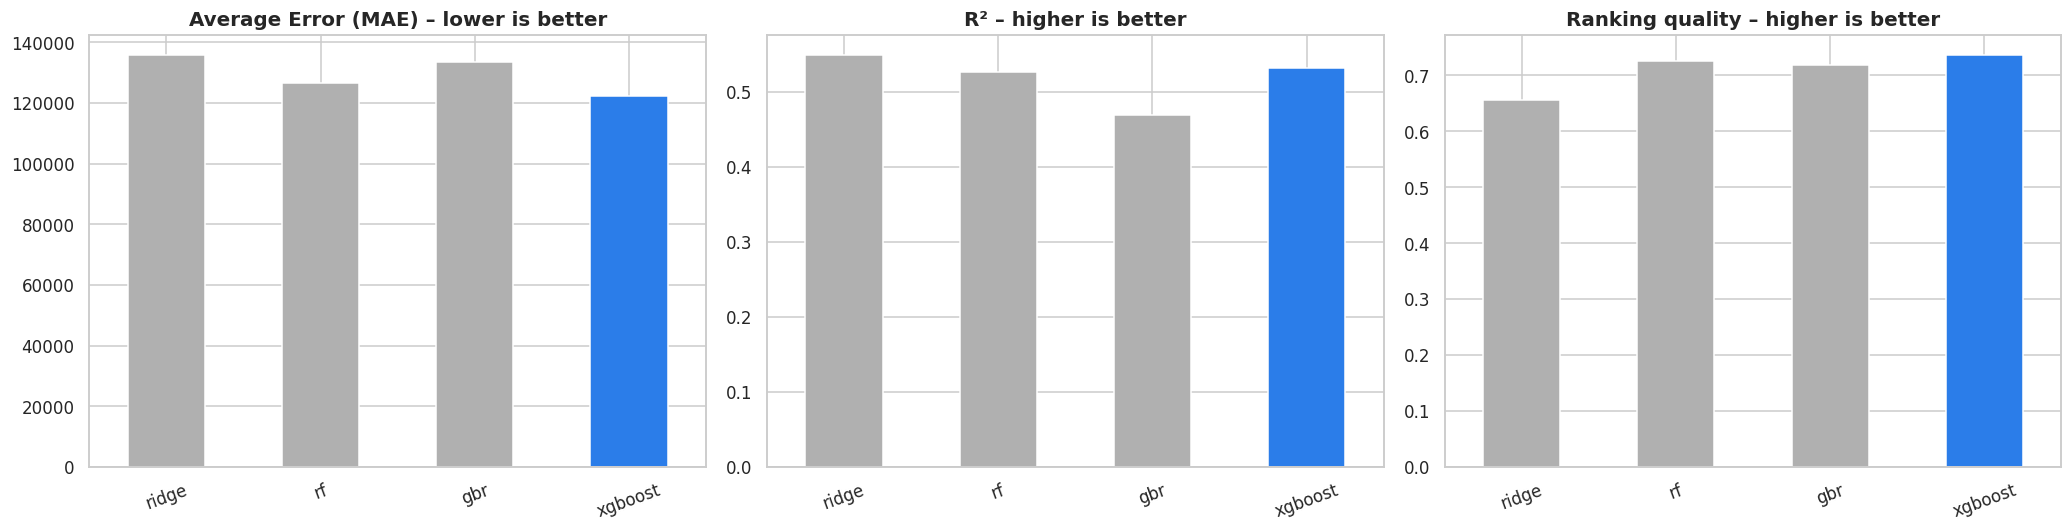

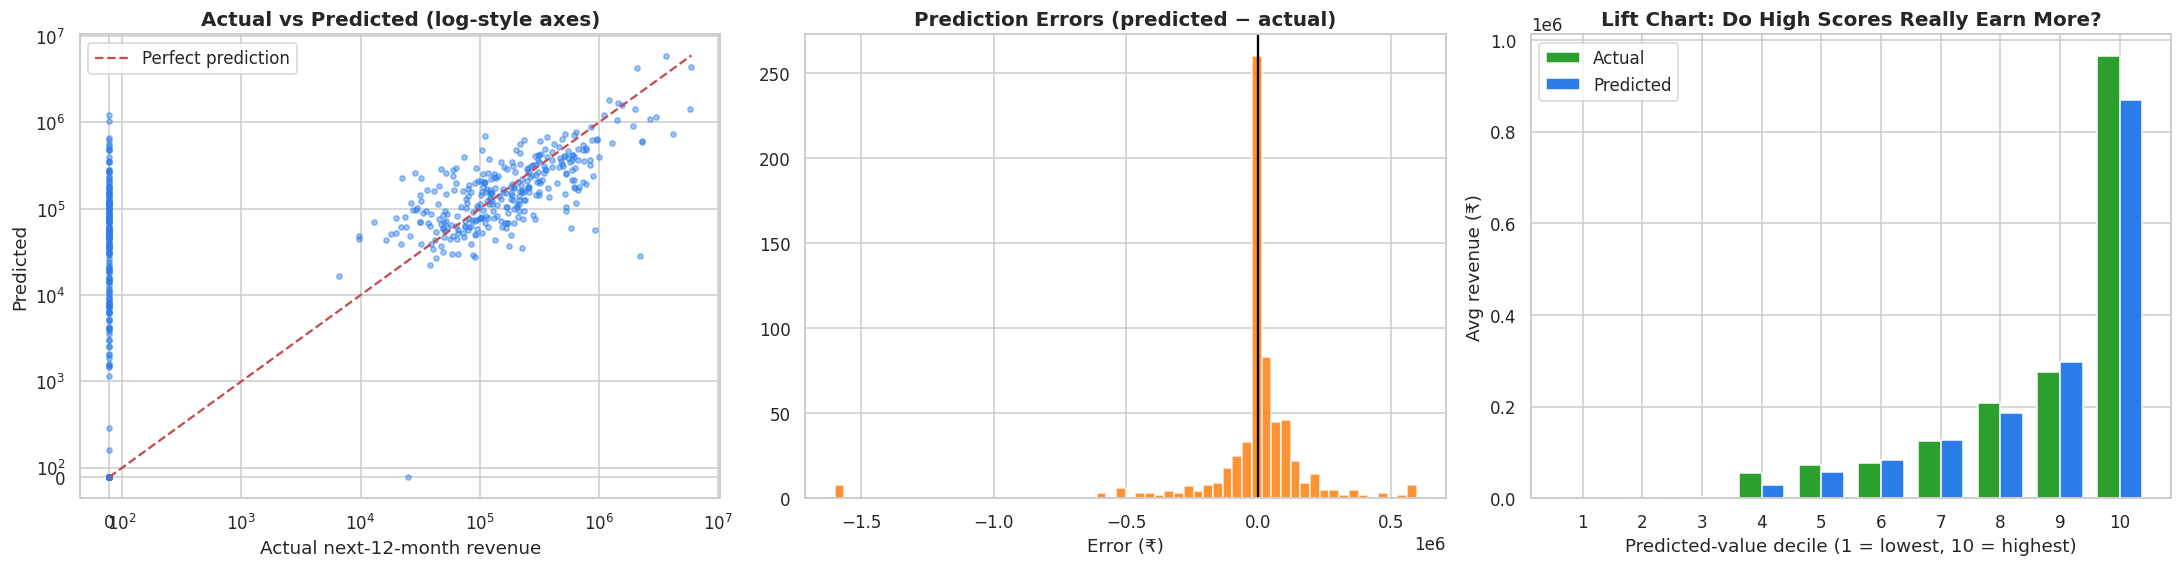

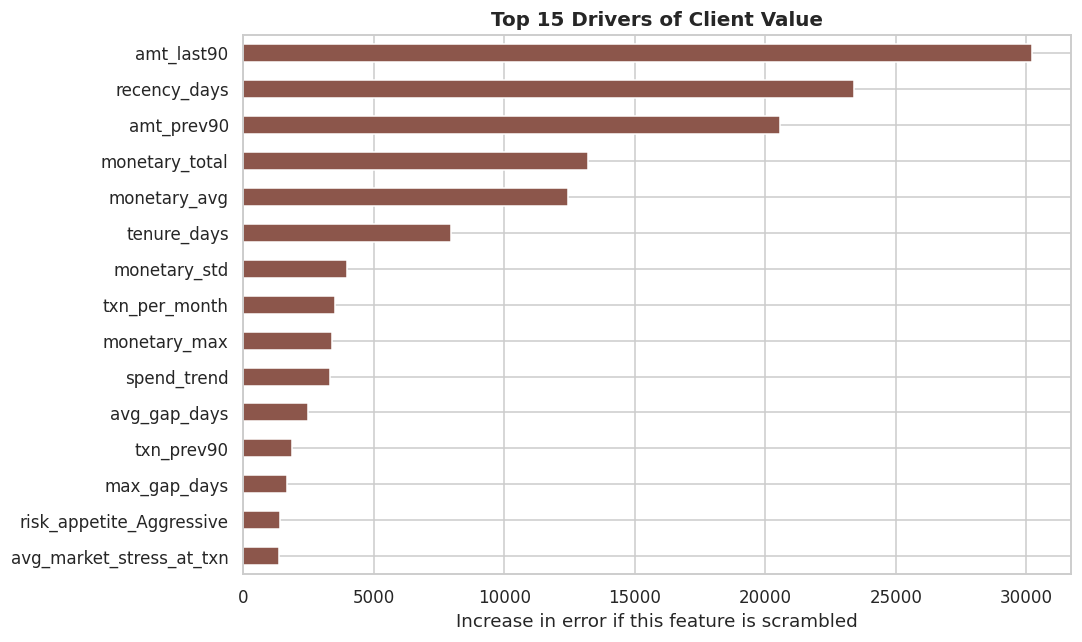

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
sdf = score_df.copy()
sdf["MAE"].plot.bar(ax=ax[0], color=["#2b7de9" if i == FINAL_KEY else "#b0b0b0" for i in sdf.index]); ax[0].set_title("Average Error (MAE) – lower is better"); ax[0].tick_params(axis="x", rotation=20)
sdf["R²"].plot.bar(ax=ax[1], color=["#2b7de9" if i == FINAL_KEY else "#b0b0b0" for i in sdf.index]); ax[1].set_title("R² – higher is better"); ax[1].axhline(0, c="black", lw=.8); ax[1].tick_params(axis="x", rotation=20)
sdf["Rank corr (Spearman)"].plot.bar(ax=ax[2], color=["#2b7de9" if i == FINAL_KEY else "#b0b0b0" for i in sdf.index]); ax[2].set_title("Ranking quality – higher is better"); ax[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
explain("How to read this", "Each bar is a different algorithm (blue = the one you selected). <b>MAE</b> = on average, how many currency units the prediction is off by per client. "
        "<b>R²</b> = share of the ups and downs in client value the model explains (1 = perfect, 0 = no better than guessing the average). "
        "<b>Ranking quality</b> = does the model put the best clients above the worst ones? For marketing/relationship priorities this is often the most useful score.")

fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))
ax[0].scatter(y_te, pred_te, s=12, alpha=.45, color="#2b7de9")
lim = max(y_te.max(), pred_te.max()); ax[0].plot([0, lim], [0, lim], "r--", label="Perfect prediction")
ax[0].set_xscale("symlog", linthresh=1e3); ax[0].set_yscale("symlog", linthresh=1e3)
ax[0].set_xlabel("Actual next-12-month revenue"); ax[0].set_ylabel("Predicted"); ax[0].set_title("Actual vs Predicted (log-style axes)"); ax[0].legend()

resid = (pred_te - y_te)
ax[1].hist(np.clip(resid, np.percentile(resid, 1), np.percentile(resid, 99)), bins=60, color="#ff7f0e", alpha=.85)
ax[1].axvline(0, color="black"); ax[1].set_title("Prediction Errors (predicted − actual)"); ax[1].set_xlabel(f"Error ({CURRENCY})")

dec = pd.DataFrame({"a": y_te.values, "p": pred_te}); dec["decile"] = pd.qcut(dec.p.rank(method="first"), 10, labels=range(1, 11))
d = dec.groupby("decile")[["a", "p"]].mean()
w_ = .38; xs = np.arange(10)
ax[2].bar(xs-w_/2, d.a, w_, label="Actual", color="#2ca02c"); ax[2].bar(xs+w_/2, d.p, w_, label="Predicted", color="#2b7de9")
ax[2].set_xticks(xs); ax[2].set_xticklabels(d.index); ax[2].set_xlabel("Predicted-value decile (1 = lowest, 10 = highest)"); ax[2].set_ylabel(f"Avg revenue ({CURRENCY})")
ax[2].set_title("Lift Chart: Do High Scores Really Earn More?"); ax[2].legend()
plt.tight_layout(); plt.show()
explain("How to read these 3 charts",
        "<b>Left:</b> every dot is a client. Dots hugging the red dashed line = accurate predictions; the vertical column at the left = clients who truly brought zero. "
        "<b>Middle:</b> a tall spike centred on 0 = errors are small and unbiased. "
        "<b>Right (most business-friendly):</b> clients are sorted into 10 buckets by predicted value. Green bars should climb steadily from left to right – "
        "meaning the top buckets truly are your most valuable clients – and be close in height to the blue bars.")

# feature importance
pi = permutation_importance(model, X_te, y_te, n_repeats=5, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error", n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).head(15)[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
imp.plot.barh(ax=ax, color="#8c564b"); ax.set_xlabel("Increase in error if this feature is scrambled"); ax.set_title("Top 15 Drivers of Client Value")
plt.tight_layout(); plt.show()
explain("How to read this", "We scramble one feature at a time and see how much worse the model gets. <b>Longer bar = the model relies on it more.</b> "
        "Typical winners: <i>recency</i> (how recently they transacted), <i>frequency</i>, <i>recent spend</i>, and <i>tenure</i>. "
        "If a market-stress feature appears, it means the client's behaviour in turbulent markets helps predict their future value.")

## 9️⃣ Survival-Adjusted CLV & Final Blend
**Survival-based CLV** = expected monthly revenue × expected number of months the client stays active in the horizon (from the Cox model).
Clients already inactive beyond the churn window are counted as lost. We then **blend** it with the ML prediction using `BLEND_WEIGHT_ML`.

In [ ]:
grid_days = np.arange(0, int(pop.tenure_days.max() + CLV_HORIZON_DAYS + 31), 15)
S = cph.predict_survival_function(cox_X, times=grid_days)      # rows = days, columns = clients
S = S[pop.index].values
months = np.arange(1, CLV_HORIZON_DAYS//30 + 1)
alive_months = np.zeros(len(pop)); ten = pop.tenure_days.values
for j in range(len(pop)):
    s0 = max(np.interp(ten[j], grid_days, S[:, j]), 1e-6)
    alive_months[j] = (np.interp(ten[j] + 30*months, grid_days, S[:, j])/s0).sum()

monthly_value = .5*(pop.monetary_total/np.maximum(pop.tenure_days/30.44, 1)) + .5*(pop.amt_last90/3)
pop["expected_active_months"] = alive_months
pop["clv_survival"] = (1-pop.churned)*monthly_value.values*alive_months

X_all = X.copy()
pop["clv_ml"] = np.clip(model.predict(X_all), 0, None)
pop["clv_blend"] = BLEND_WEIGHT_ML*pop.clv_ml + (1-BLEND_WEIGHT_ML)*pop.clv_survival
pop["churn_risk_score"] = ph.rank(pct=True).reindex(pop.index)

te = pop.loc[X_te.index]
cmp = pd.DataFrame({k: evaluate(te.future_clv, te[k]) for k in ["clv_ml", "clv_survival", "clv_blend"]}).T.round(3)
cmp.index = ["ML regression", "Survival-based", f"Blend ({BLEND_WEIGHT_ML:.0%} ML)"]
print("Held-out test clients:"); display(cmp)

Held-out test clients:


,MAE,RMSE,R²,Rank corr (Spearman)
ML regression,122162.078,343976.939,0.532,0.736
Survival-based,128071.753,370460.655,0.457,0.788
Blend (70% ML),115724.172,289639.128,0.668,0.752


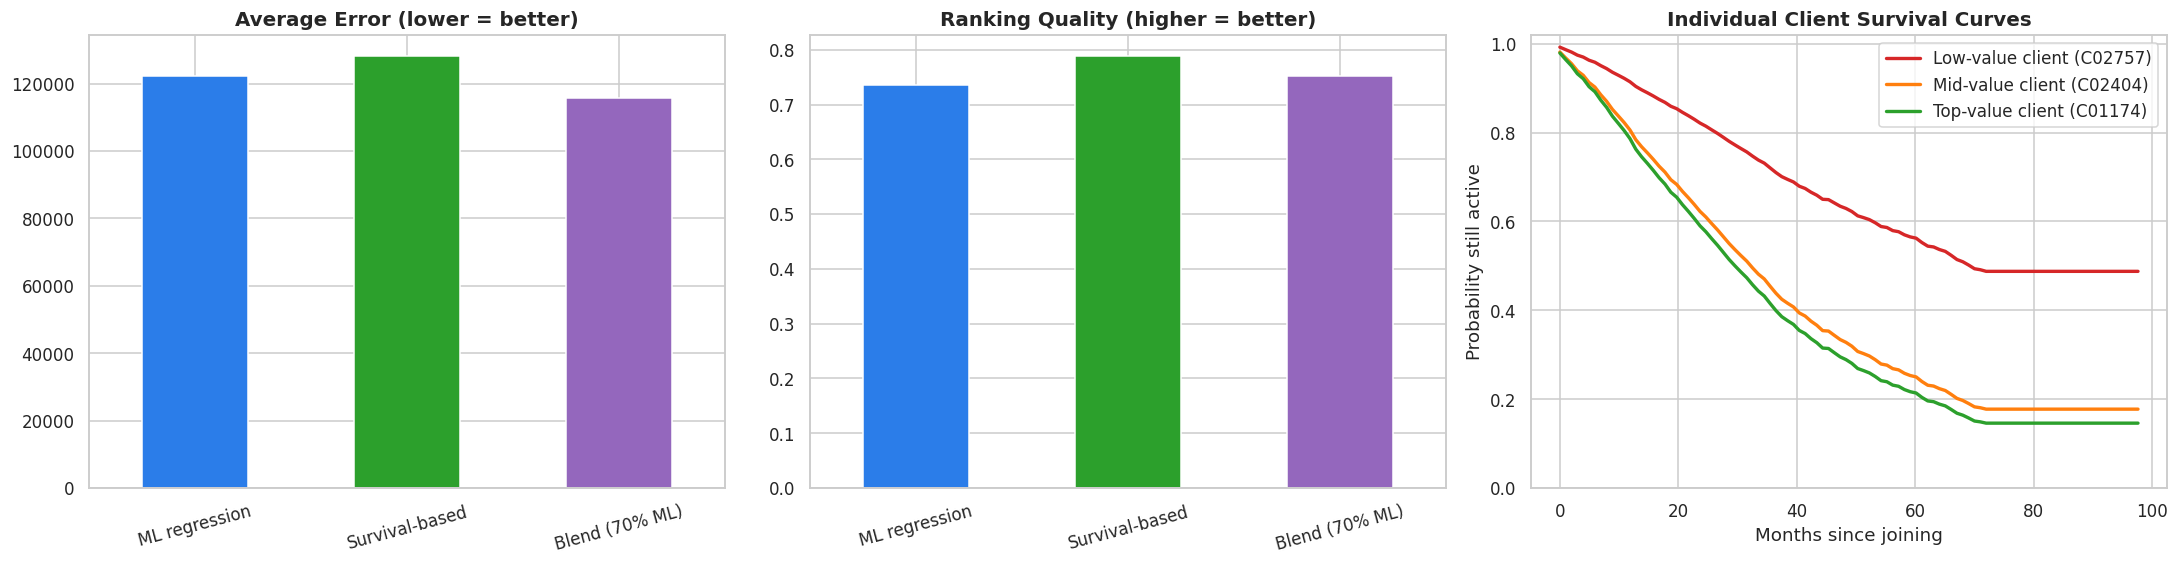

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5.3))
cmp["MAE"].plot.bar(ax=ax[0], color=["#2b7de9", "#2ca02c", "#9467bd"]); ax[0].set_title("Average Error (lower = better)"); ax[0].tick_params(axis="x", rotation=15)
cmp["Rank corr (Spearman)"].plot.bar(ax=ax[1], color=["#2b7de9", "#2ca02c", "#9467bd"]); ax[1].set_title("Ranking Quality (higher = better)"); ax[1].tick_params(axis="x", rotation=15)

# example clients: survival curves
sample = pop.sort_values("clv_blend").iloc[[int(len(pop)*.1), int(len(pop)*.5), int(len(pop)*.95)]]
cols = ["#d62728", "#ff7f0e", "#2ca02c"]; labs = ["Low-value client", "Mid-value client", "Top-value client"]
Sfull = cph.predict_survival_function(cox_X.loc[sample.index], times=np.arange(0, 3000, 30))
for (cid, row), c, l in zip(sample.iterrows(), cols, labs):
    ax[2].plot(Sfull.index/30.44, Sfull[cid], color=c, lw=2.2, label=f"{l} ({cid})")
ax[2].set_xlabel("Months since joining"); ax[2].set_ylabel("Probability still active"); ax[2].set_ylim(0, 1.02); ax[2].set_title("Individual Client Survival Curves"); ax[2].legend()
plt.tight_layout(); plt.show()
explain("How to read this", "<b>Left & middle:</b> compare the three ways of estimating CLV – the survival approach knows <i>how long</i> clients stay, the ML approach knows "
        "<i>how much</i> they spend; blending often gives the best balance. <b>Right:</b> personal 'loyalty curves' for three example clients – a curve that stays high means a long relationship.")

## 🔟 Business Dashboard – Segments, Tiers & Where the Money Is

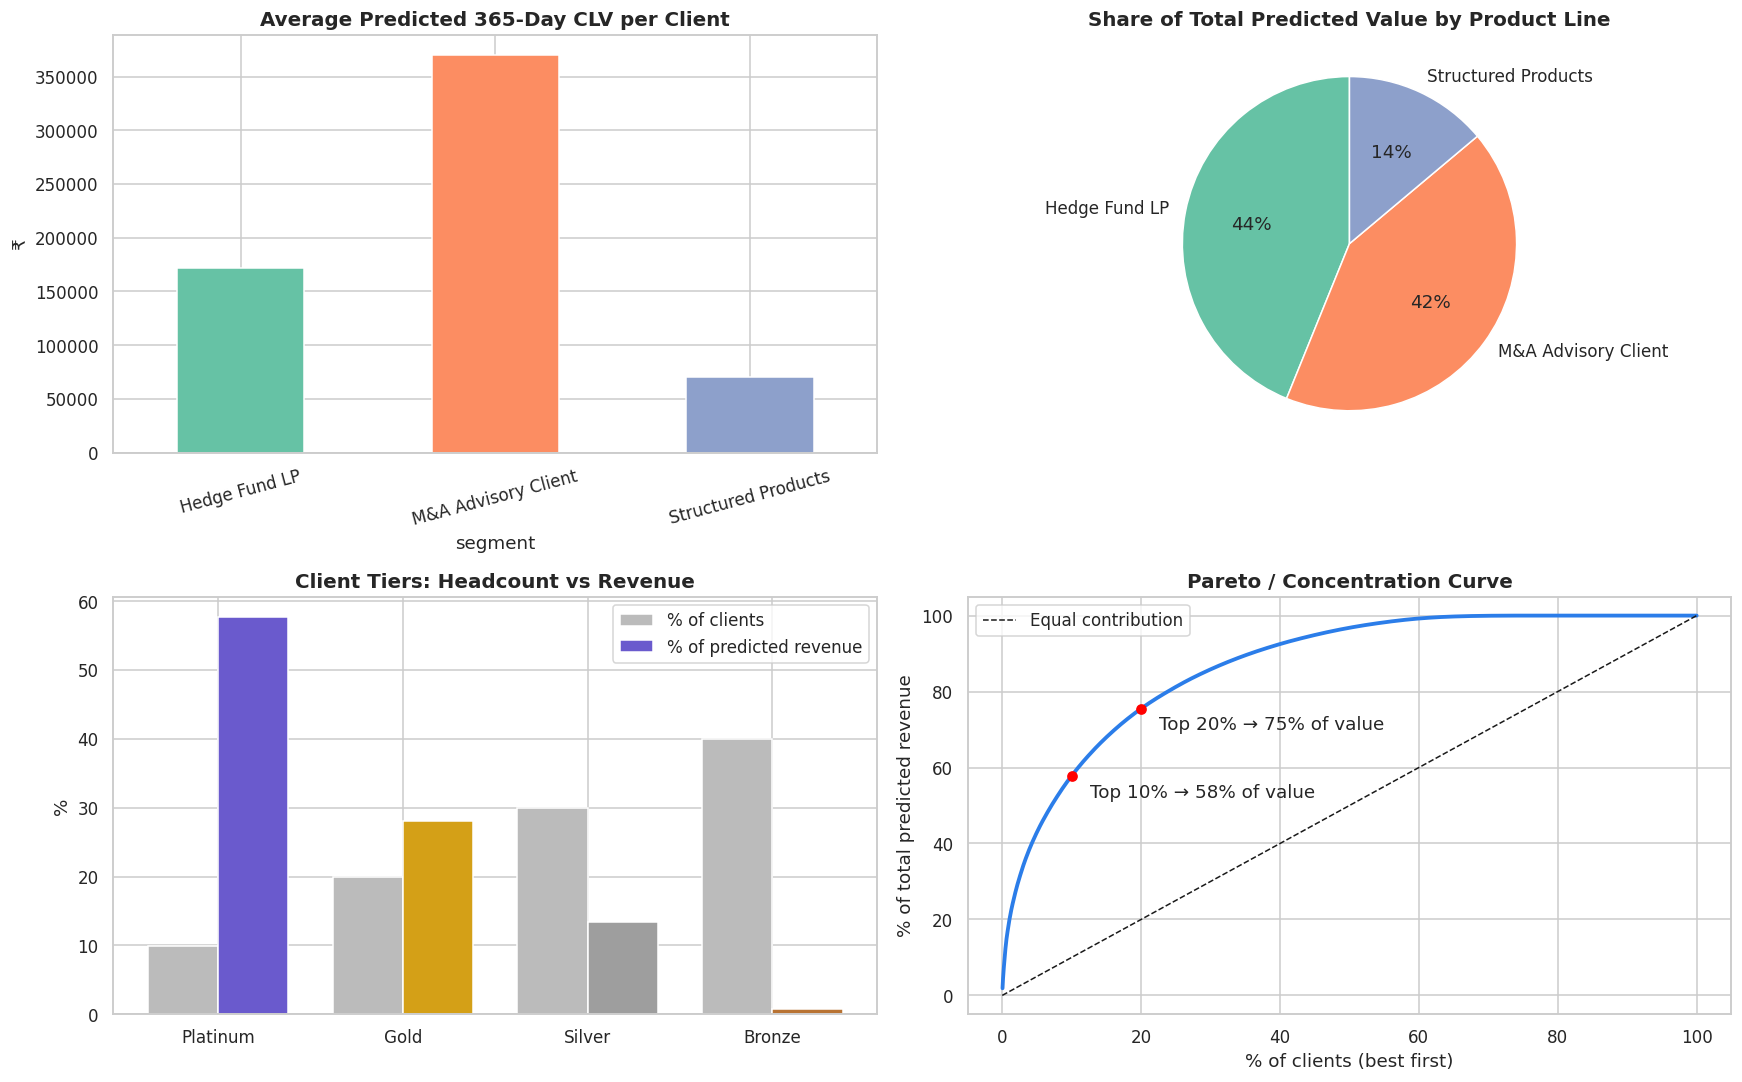

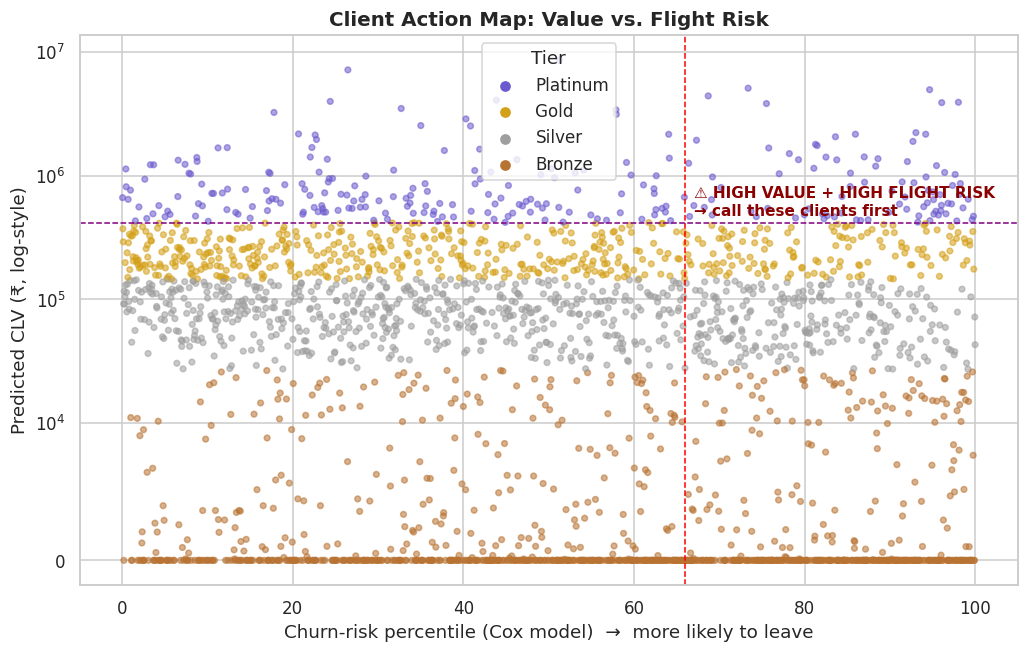

In [ ]:
cuts = TIER_CUTS
rank = pop.clv_blend.rank(pct=True, ascending=False)
pop["tier"] = np.select([rank <= cuts["Platinum"], rank <= cuts["Gold"], rank <= cuts["Silver"]], ["Platinum", "Gold", "Silver"], "Bronze")
tier_order = ["Platinum", "Gold", "Silver", "Bronze"]; tier_col = {"Platinum": "#6a5acd", "Gold": "#d4a017", "Silver": "#9e9e9e", "Bronze": "#b87333"}

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
seg = pop.groupby(SEGMENT_COL)["clv_blend"].agg(["mean", "sum", "count"])
seg["mean"].plot.bar(ax=ax[0,0], color=sns.color_palette("Set2")); ax[0,0].set_title(f"Average Predicted {CLV_HORIZON_DAYS}-Day CLV per Client"); ax[0,0].set_ylabel(CURRENCY); ax[0,0].tick_params(axis="x", rotation=15)
(seg["sum"]/1e6).plot.pie(ax=ax[0,1], autopct="%1.0f%%", colors=sns.color_palette("Set2"), startangle=90, ylabel=""); ax[0,1].set_title("Share of Total Predicted Value by Product Line")

tt = pop.groupby("tier")["clv_blend"].agg(["sum", "count"]).reindex(tier_order)
w2 = .38; xs = np.arange(4)
ax[1,0].bar(xs-w2/2, tt["count"]/tt["count"].sum()*100, w2, label="% of clients", color="#bbbbbb")
ax[1,0].bar(xs+w2/2, tt["sum"]/tt["sum"].sum()*100, w2, label="% of predicted revenue", color=[tier_col[t] for t in tier_order])
ax[1,0].set_xticks(xs); ax[1,0].set_xticklabels(tier_order); ax[1,0].set_ylabel("%"); ax[1,0].set_title("Client Tiers: Headcount vs Revenue"); ax[1,0].legend()

srt = pop.clv_blend.sort_values(ascending=False).values; cum = np.cumsum(srt)/srt.sum()*100; px = np.arange(1, len(srt)+1)/len(srt)*100
ax[1,1].plot(px, cum, color="#2b7de9", lw=2.5); ax[1,1].plot([0, 100], [0, 100], "k--", lw=1, label="Equal contribution")
for p in (10, 20):
    v = cum[int(len(srt)*p/100)-1]; ax[1,1].scatter([p], [v], color="red", zorder=5); ax[1,1].annotate(f"Top {p}% → {v:.0f}% of value", (p, v), textcoords="offset points", xytext=(12, -14))
ax[1,1].set_xlabel("% of clients (best first)"); ax[1,1].set_ylabel("% of total predicted revenue"); ax[1,1].set_title("Pareto / Concentration Curve"); ax[1,1].legend()
plt.tight_layout(); plt.show()
explain("How to read this 2×2 dashboard",
        "<b>Top-left:</b> which product line has the most valuable average client. <b>Top-right:</b> which product contributes most of the total money. "
        "<b>Bottom-left:</b> the grey bar is how many clients are in each tier and the coloured bar is how much revenue they bring – Platinum should be a tiny group with a huge revenue share. "
        "<b>Bottom-right:</b> the further the blue curve bows above the dashed diagonal, the more your revenue depends on a small elite of clients (protect them!).")

# churn risk vs value matrix
fig, ax = plt.subplots(figsize=(11, 6.5))
sc = ax.scatter(pop.churn_risk_score*100, pop.clv_blend, c=pop.tier.map(tier_col), s=14, alpha=.55)
ax.set_yscale("symlog", linthresh=1e4); ax.axvline(66, color="red", ls="--", lw=1); ax.axhline(pop.clv_blend.quantile(.9), color="purple", ls="--", lw=1)
ax.text(67, pop.clv_blend.quantile(.9)*1.15, "⚠️ HIGH VALUE + HIGH FLIGHT RISK\n→ call these clients first", color="darkred", fontsize=10, fontweight="bold")
ax.set_xlabel("Churn-risk percentile (Cox model)  →  more likely to leave"); ax.set_ylabel(f"Predicted CLV ({CURRENCY}, log-style)")
ax.set_title("Client Action Map: Value vs. Flight Risk")
for t in tier_order: ax.scatter([], [], c=tier_col[t], label=t)
ax.legend(title="Tier"); plt.show()
explain("How to read this", "Every dot is a client. Height = predicted value, horizontal position = risk of leaving. <b>Top-right corner</b> = valuable clients who might leave soon – "
        "the best targets for retention effort (relationship calls, fee offers, tailored products). Top-left = safe stars; bottom-right = low-value leavers (little action needed).")

## 1️⃣1️⃣ Executive Summary & Export

In [ ]:
top10_share = pop.clv_blend.nlargest(int(len(pop)*.1)).sum()/pop.clv_blend.sum()
at_risk = pop[(pop.tier.isin(["Platinum", "Gold"])) & (pop.churn_risk_score >= .66)]
best_seg = pop.groupby(SEGMENT_COL)["clv_blend"].mean().idxmax()
summary = f"""
<b>Market:</b> {TICKER} – annual volatility {ann_vol:.1%}, max drawdown {max_dd:.1%}, Sharpe {sharpe:.2f}, beta {beta:.2f} vs {BENCHMARK}.<br>
<b>Clients modeled:</b> {len(pop):,} &nbsp;|&nbsp; <b>Already churned:</b> {pop.churned.mean():.1%} &nbsp;|&nbsp; <b>Median lifetime:</b> {('%.0f months' % med) if np.isfinite(med) else 'not reached yet (most clients stay >' + str(int(surv.duration_m.max())) + ' months)'}.<br>
<b>Predicted {CLV_HORIZON_DAYS}-day revenue:</b> {money(pop.clv_blend.sum())} in total, {money(pop.clv_blend.mean())} per client.<br>
<b>Concentration:</b> the top 10% of clients generate {top10_share:.0%} of predicted revenue. Most valuable product line: <b>{best_seg}</b>.<br>
<b>Retention alert:</b> {len(at_risk)} Platinum/Gold clients are also in the highest churn-risk third – prioritise them.<br>
<b>ML model ({FINAL_KEY}):</b> R² = {score_df.loc[FINAL_KEY, 'R²']:.2f}, ranking correlation = {score_df.loc[FINAL_KEY, 'Rank corr (Spearman)']:.2f}.
"""
display(HTML(f"<div style='background:#f3fff3;border-left:6px solid #2ca02c;padding:14px 18px;font-size:15px;line-height:1.7;color:#111'><b>📌 EXECUTIVE SUMMARY</b><br>{summary}</div>"))
if DEMO_MODE:
    display(HTML("<div style='background:#fff4e5;border-left:6px solid #ff9800;padding:10px 14px;color:#111'>⚠️ Some market data could not be downloaded, so <b>demo prices</b> were used. Check your ticker names / internet and re-run.</div>"))

out_cols = [SEGMENT_COL, "tier", "clv_ml", "clv_survival", "clv_blend", "expected_active_months", "churn_risk_score", "churned", "recency_days", "frequency", "monetary_total"]
scorecard = pop[out_cols].sort_values("clv_blend", ascending=False).round(2)
display(scorecard.head(15))
scorecard.to_csv("client_clv_scorecard.csv")
print("💾 Saved: client_clv_scorecard.csv")
try:
    from google.colab import files; files.download("client_clv_scorecard.csv")
except Exception:
    pass

,segment,tier,clv_ml,clv_survival,clv_blend,expected_active_months,churn_risk_score,churned,recency_days,frequency,monetary_total
customer_id,,,,,,,,,,,
C02270,M&A Advisory Client,Platinum,6360886.000,13955061.03,8639138.31,10.90,0.51,0,3,5,7588575.28
C01688,M&A Advisory Client,Platinum,8376075.500,4338548.43,7164817.53,10.90,0.26,0,6,24,23685264.31
C01268,M&A Advisory Client,Platinum,5817679.500,3410576.78,5095548.53,10.21,0.73,0,66,31,30390914.39
C02306,M&A Advisory Client,Platinum,4160103.250,6816346.39,4956976.42,10.30,0.95,0,7,5,7657298.72
C02735,M&A Advisory Client,Platinum,3998838.500,5377270.02,4412367.75,10.44,0.69,0,49,27,30554727.03
C02426,Hedge Fund LP,Platinum,4558620.500,2945080.07,4074558.27,10.91,0.44,0,0,84,17805970.50
C00016,M&A Advisory Client,Platinum,4898063.000,1850366.10,3983753.83,11.86,0.24,0,141,42,21945772.26
C01492,M&A Advisory Client,Platinum,4611074.000,2310609.63,3920934.64,9.47,0.98,0,156,11,14505883.56
C00771,M&A Advisory Client,Platinum,1447756.375,9602509.56,3894182.24,10.12,0.96,0,29,3,4900714.30


💾 Saved: client_clv_scorecard.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### 🔧 Quick tuning guide
| I want to… | Change this in the Control Panel |
|---|---|
| Analyse a different stock/market | `TICKER`, `BENCHMARK` (e.g. `"AAPL"` + `"^GSPC"`, or `"HDFCBANK.NS"` + `"^NSEI"`) |
| Try another algorithm | `MODEL_CHOICE = "gbr"` / `"rf"` / `"ridge"` / `"xgboost"` |
| Reduce over-fitting | lower `max_depth`, `learning_rate`; raise `min_child_weight` / `min_samples_leaf`; lower `n_estimators` |
| Get more accuracy | raise `n_estimators`, or set `RUN_TUNING = True` |
| Predict a longer/shorter period | `CLV_HORIZON_DAYS` (e.g. 180, 730) |
| Change what counts as "churned" | `CHURN_INACTIVITY_DAYS` |
| Use real client data | `CUSTOMERS_CSV`, `TRANSACTIONS_CSV` |
| Make clients more/less sensitive to market stress | `MARKET_STRESS_IMPACT` |

*Educational analytics – not investment advice. Simulated client data is illustrative; validate with real client data before business use.*